In [ ]:
import pandas as pd
import numpy as np
# from datetime import datetime

import catboost

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, mean_absolute_error

from catboost.utils import get_roc_curve
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import dtw

Есть данные о тендерной активности заказчиков и поставщиков. Обучаем модель которая будет предсказывать изменение цены по итогам тендера в зависимости от ТН, региона, поставщика, количества участников конкурса. Изменение цены указано в %, цена может только уменьшаться относительно начальной максимальной цены. Умеьшение цены происходит за счет конкурирующих предложений поставщиков.

In [ ]:
# считываем данные с начала прошлого года, по дням
# Создаем список для хранения отдельных датафреймов
dfs = []

# Цикл от 1 до 12 для чтения каждого файла
for i in range(1, 14):
    file_name = f'Тендеры_{i}.csv'
    # Читаем файл и добавляем его в список
    df_current = pd.read_csv(file_name)
    dfs.append(df_current)

# Объединяем все таблицы из списка в одну общую
df = pd.concat(dfs, ignore_index=True).sort_values(by = ['TendDt'])
# Цена другого может быть не заполнена если участников всего один, заполняю актуальной ценой
df['ЦенаДругого'] = df['ЦенаДругого'].fillna(df['PricePack_contr'])

df['Наименование'] = df['Наименование'].str.upper()

df.tail(3)

,TendDt,TenderYear,TenderMonth,Наименование,МНН,Статус,Форма,ФО,Регион,ТипЗакупки,...,ДругойУчастник,СтруктураЛота,СуммаКонтракт,КвоКонтракт,ЦенаКонтракта,КвоСпецЛота,КвоУчастников,PricePack_contr,ЦенаДругого,ИзменениеЦены
7959,2026-06-10,2026,6,НЕОЦИТОТЕКТ,Иммуноглобулин человека антицитомегаловирусный,размещение завершено,закупка у единственного поставщика,Центральный ФО,Владимирская область,Госпитальные закупки,...,Неизвестный поставщик,Однопозиционный,21000.00,3.0,21000.00,1,1,7000.00,0.00,0.000000
8605,2026-06-11,2026,6,ЭНПЛЕЙТ,Ромиплостим,размещение завершено,закупка у единственного поставщика,Приволжский ФО,Республика Башкортостан,Госпитальные закупки,...,Неизвестный поставщик,Однопозиционный,165805.64,4.0,165805.64,1,1,41451.41,41451.41,0.000024
7392,2026-06-11,2026,6,АНТИТРОМБИН III ЧЕЛОВЕЧЕСКИЙ,Антитромбин III,размещение завершено,закупка у единственного поставщика,Центральный ФО,Москва,Госпитальные закупки,...,Неизвестный поставщик,Однопозиционный,183425.00,5.0,183425.00,1,1,36685.00,36685.00,0.000000


In [ ]:
df['TendDt'].count()

31605

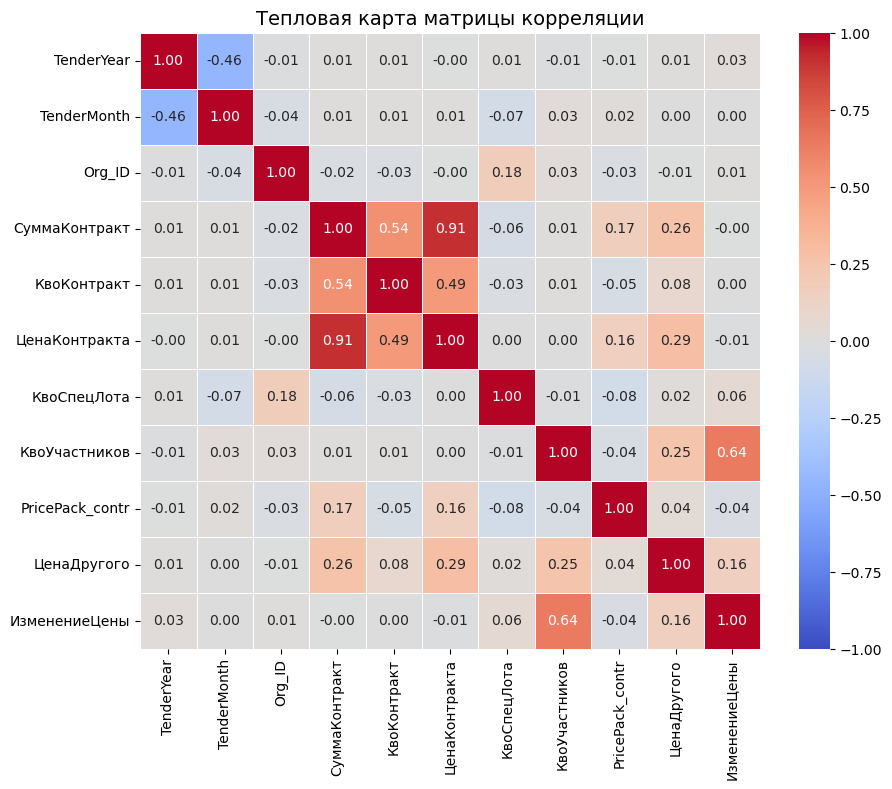

In [ ]:
# взаимосвязь фичей друг с другом
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,  # Отображает коэффициенты внутри ячеек
    cmap="coolwarm",  # Цветовая схема (синий — негативная, красный — позитивная корреляция)
    fmt=".2f",  # Округление значений до 2 знаков после запятой
    vmin=-1,  # Минимальное значение шкалы
    vmax=1,  # Максимальное значение шкалы
    linewidths=0.5,  # Зазоры между ячейками
)

plt.title("Тепловая карта матрицы корреляции", fontsize=14)
plt.show()

In [ ]:
# вариативность таргета
df['ИзменениеЦены'].describe()

count    31605.000000
mean         1.427845
std          5.498293
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         95.191597
Name: ИзменениеЦены, dtype: float64

Несбалансированные данные с сильным «нулевым хвостом». Более 75% всех значений (включая медиану) равны нулю то есть нет изменений цены, при этом максимальное значение доходит до 95.19.Обычное обучение CatBoostRegressor «из коробки» на таких данных будет давать плохой результат: модель либо занизит все предсказания до нуля, либо будет сильно ошибаться на больших значениях из-за высокого стандартного отклонения (std = 5.49).

Два этапа решения задачи:

1. Классификатор (CatBoostClassifier): Обучается отвечать на вопрос: «Изменится ли цена вообще?» (таргет: y == 0 или y > 0).
2. Регрессор (CatBoostRegressor): Обучается только на тех строках, где ИзменениеЦены > 0. Он предсказывает величину изменения.

Финальный прогноз: Результат Классификатора (вероятность) умножается на результат Регрессора.

Какие признаки влияют на изменение цены?
В  базовой регрессионной модели на полных данныъх множно понять какие признаки важны.
Признаки ЦенаДругого становится известным в конце торгов и поэтому сразу исключим их из списка влияющих переменных (фичей).
Так как более 75% данных содержат 0.0 изменение цены, стандартная функция потерь RMSE заставит модель игнорировать редкие скачки цен.
Параметр loss_function='MAE' (Mean Absolute Error) для модели выше выбран, чтобы модель была более устойчива к сильным выбросам на хвосте распределения.

Алгоритм смотрит на все деревья в модели. Для каждого признака вычисляется, насколько сильно меняются предсказания модели, когда по этому признаку происходит разбиение в узлах деревьев. Чем сильнее меняется прогноз и чем чаще используется признак, тем выше его важность

In [ ]:
# выделяем целевую переменную и признаки
target = 'ИзменениеЦены'

# удаляем цену последнего участника торгов, она неизвестна на старте и ID поставщика тоже не нужен,достаточно названия
# ЦенаКонтракта - общая сумма по всем ТН в контракте связана с СуммаКонтракат - стоимость конкретного ТН, поэтому удаляем
features_to_drop = [target, 'ЦенаДругого', 'Org_ID', 'ЦенаКонтракта']
X = df.drop(columns=[col for col in features_to_drop if col in df.columns])
y = df[target]

# определяем категориальные признаки  типа object
cat_features = X.select_dtypes(include=['object']).columns.tolist()


# приводим категориальные признаки к типу string (требование CatBoost)
for col in cat_features:
    X[col] = X[col].astype(str)

# обучаем модель CatBoost
# функция потерь MAE, так как в целевой переменной много тяжелых выбросов (максимум 95)
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

model.fit(X, y, cat_features=cat_features)

# важность признаков
feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)


0:	learn: 1.3599770	total: 231ms	remaining: 1m 55s
100:	learn: 0.9200607	total: 7.12s	remaining: 28.1s
200:	learn: 0.8602637	total: 14.9s	remaining: 22.1s
300:	learn: 0.8432868	total: 23.6s	remaining: 15.6s
400:	learn: 0.8355779	total: 32.6s	remaining: 8.05s
499:	learn: 0.8304422	total: 41.8s	remaining: 0us
            Feature  Importance
17    КвоУчастников   38.398567
3      Наименование    7.594139
11        Поставщик    7.183553
4               МНН    7.126068
6             Форма    6.333286
18  PricePack_contr    5.987854
8            Регион    5.715895
1        TenderYear    4.893894
16      КвоСпецЛота    4.521415
0            TendDt    3.770883
15      КвоКонтракт    1.856916
7                ФО    1.721194
12   ДругойУчастник    1.489499
14    СуммаКонтракт    1.353068
9        ТипЗакупки    0.615547
2       TenderMonth    0.579095
10         Заказчик    0.460696
13    СтруктураЛота    0.398434
5            Статус    0.000000


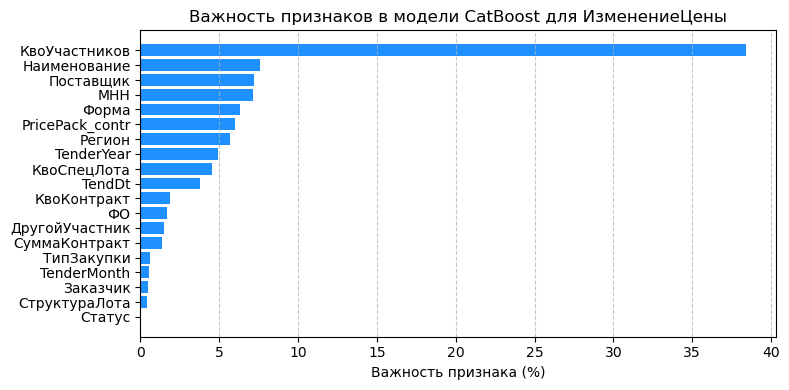

In [ ]:
# визуал важности признаков
plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='dodgerblue')
plt.xlabel('Важность признака (%)')
plt.title('Важность признаков в модели CatBoost для ИзменениеЦены')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


В какую сторону признаки двигают динамику цены? SHAP (SHapley Additive exPlanations) values.
В отличие от стандартного Feature Importance (который показывает лишь частоту или полезность использования признака при построении деревьев),
SHAP-значения показывают, как конкретное значение признака двигает прогноз вверх или вниз.
Алгоритм перебирает всеозможные комбинации признаков, считает маржинальный вклад кадой комбинации в предсказание и выдает взвешенное среднее по каждому признаку.

In [ ]:
# Используем те же X, y и cat_features из предыдущего шага
shap_pool = Pool(X, y, cat_features=cat_features)

# SHAP-значения напрямую из обученной модели
# Возвращает матрицу размера (количество_строк x количество_признаков + 1)
# Последний столбец — это базовое (среднее) значение прогноза
shap_values = model.get_feature_importance(shap_pool, type='ShapValues')

# Отделяем матрицу вкладов признаков от базового значения
shap_interactions = shap_values[:, :-1]
base_value = shap_values[0, -1]

print(f"Базовое ожидаемое изменение цены (смещение): {base_value:.4f}")


Базовое ожидаемое изменение цены (смещение): 1.0104


Функция отрисовки гарфика покажет влияние фичи (Поставщик или Наименование или другое) на динамику цены в торгах.

Поставщики в верхней части графика (сдвиг вправо, SHAP > 0):Точки этих компаний уходят далеко в положительную сторону. Контракты с этими поставщиками систематически приводят к росту метрики ИзменениеЦены. Модель «подозревает» их в нестабильном ценообразовании.

Поставщики в нижней части графика (сдвиг влево, SHAP < 0):Их распределение сгруппировано левее нуля.Их присутствие в тендере — это маркер стабильности. Модель ожидает стабильность цены в тендере без высокой конкуренции, когда видит их.

Плотность точек (ширина "облака"):Если у поставщика узкое, кучное облако около 0 — он ведет себя предсказуемо во всех сделках.Если у поставщика длинный «хвост» вправо или влево — в большинстве тендеров он стабилен, но в некоторых закупках генерирует динамику цены.

In [ ]:
def snap_graph(df, column, shap_values_matrix, feature_names):
    """
    Строит график распределения SHAP-вкладов для топ-15 значений категории.

    Параметры:
    df: исходный DataFrame (должен содержать колонку column)
    column: название категориальной колонки (строка)
    shap_values_matrix: матрица SHAP-значений (двухмерный массив numpy или объект shap)
    feature_names: список или Index с именами фичей в том порядке, в каком они шли на вход SHAP
    """
    feature_list = list(feature_names)
    if column not in feature_list:
        raise ValueError(f"Колонка '{column}' не найдена в списке фичей")

    supplier_idx = feature_list.index(column)

    if hasattr(shap_values_matrix, 'values'):
        shap_vector = shap_values_matrix.values[:, supplier_idx]
    else:
        shap_vector = shap_values_matrix[:, supplier_idx]

    supplier_shap_df = pd.DataFrame({
        column : df[column].values,
        'SHAP_Value': shap_vector
    })

    top_suppliers = supplier_shap_df[column].value_counts().head(15).index
    filtered_df = supplier_shap_df[supplier_shap_df[column].isin(top_suppliers)].copy()

    # Сортировка: сверху те, кто сильнее всего завышает цену (SHAP > 0)
    ordered_suppliers = filtered_df.groupby(column)['SHAP_Value'].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(12, 10))

    # Визуализация распределения
    sns.boxplot(
        data=filtered_df, y=column, x='SHAP_Value', order=ordered_suppliers,
        hue=column, legend=False, palette='vlag', fliersize=0, ax=ax
    )
    sns.stripplot(
        data=filtered_df, y=column, x='SHAP_Value', order=ordered_suppliers,
        color='crimson', alpha=0.25, size=3, jitter=0.22, ax=ax
    )

    # Линия нулевого эффекта
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

    # --- БИЗНЕС-РАЗМЕТКА ЗОН ---
    x_min, x_max = filtered_df['SHAP_Value'].min(), filtered_df['SHAP_Value'].max()
    # Расширим границы для заливки фона
    padding = (x_max - x_min) * 0.1

    # Зеленая зона (Стабильность)
    ax.axvspan(x_min - padding, 0, color='green', alpha=0.04, label='Зона стабильности цены')
    # Красная зона (Риск)
    ax.axvspan(0, x_max + padding, color='red', alpha=0.04, label='Зона турбулентности цены')

    # Настройка осей и текста
    ax.set_xlim(x_min - padding/2, x_max + padding/2)
    ax.set_title(f'Анализ надежности фичи: {column}\n(Влияние на изменение цены по SHAP)', fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel('Вклад в изменение цены (SHAP value)', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Топ-15 {column} по количеству тендеров', fontsize=12)

    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

    plt.tight_layout()
    plt.show()


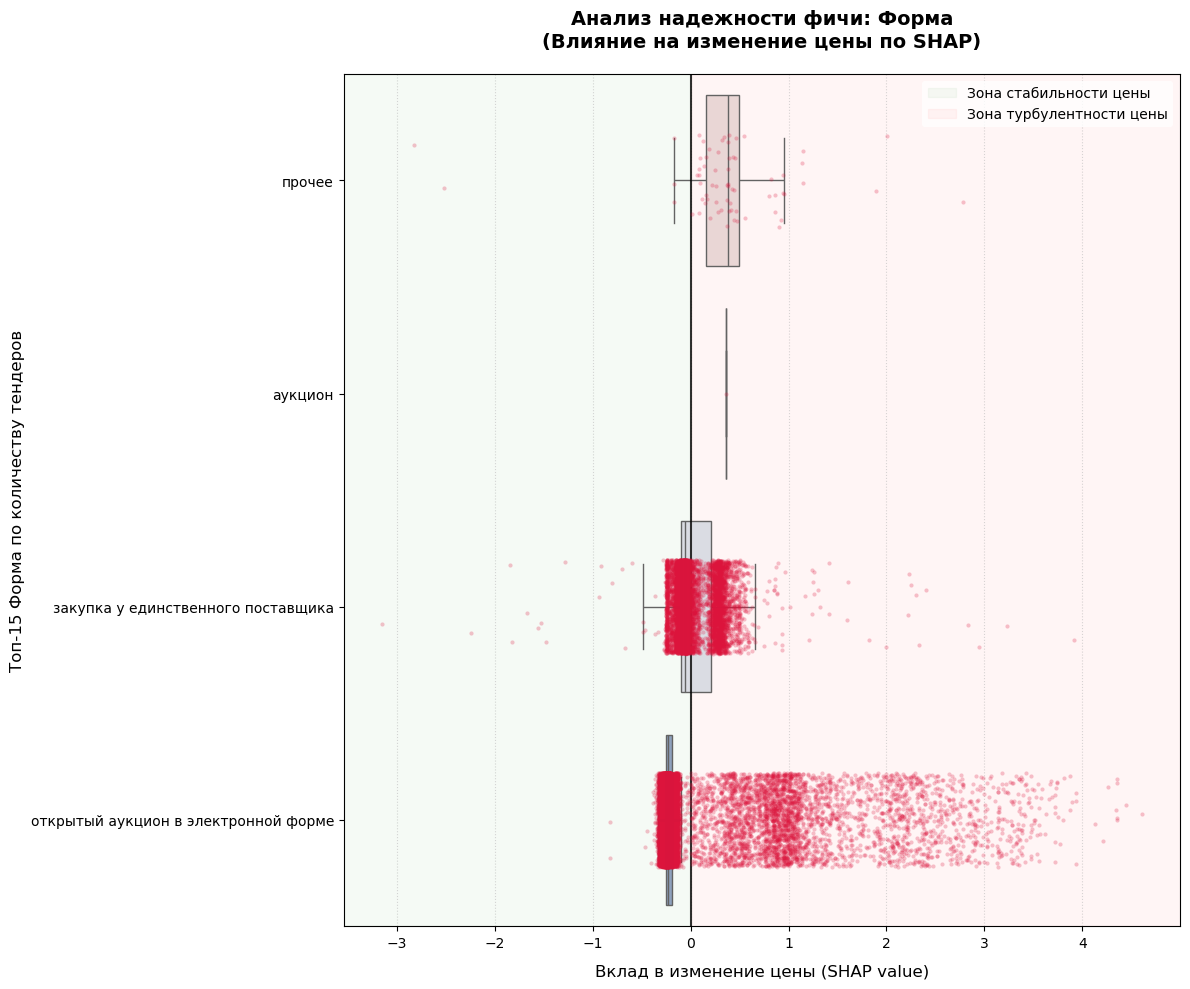

In [ ]:
# Как Форма тендера влияет на изменение цены?
snap_graph(
    df=df,
    column='Форма',
    shap_values_matrix=shap_values, # матрица SHAP (обычно n_samples x n_features)
    feature_names=X.columns
)


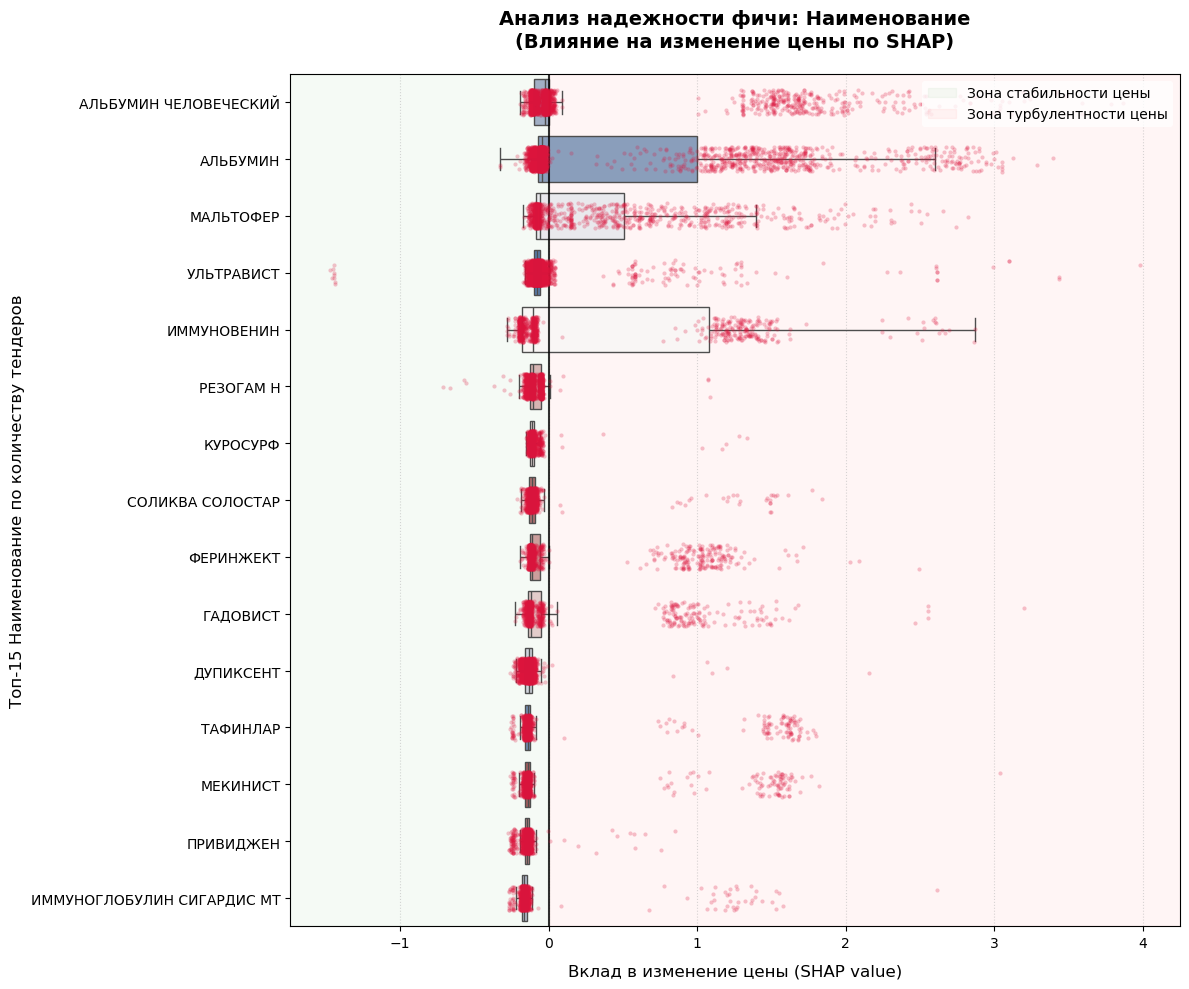

In [ ]:
# Как Торговое наименование влияет на изменение цены?
snap_graph(
    df=df,
    column='Наименование',
    shap_values_matrix=shap_values, # матрица SHAP (обычно n_samples x n_features)
    feature_names=X.columns
)

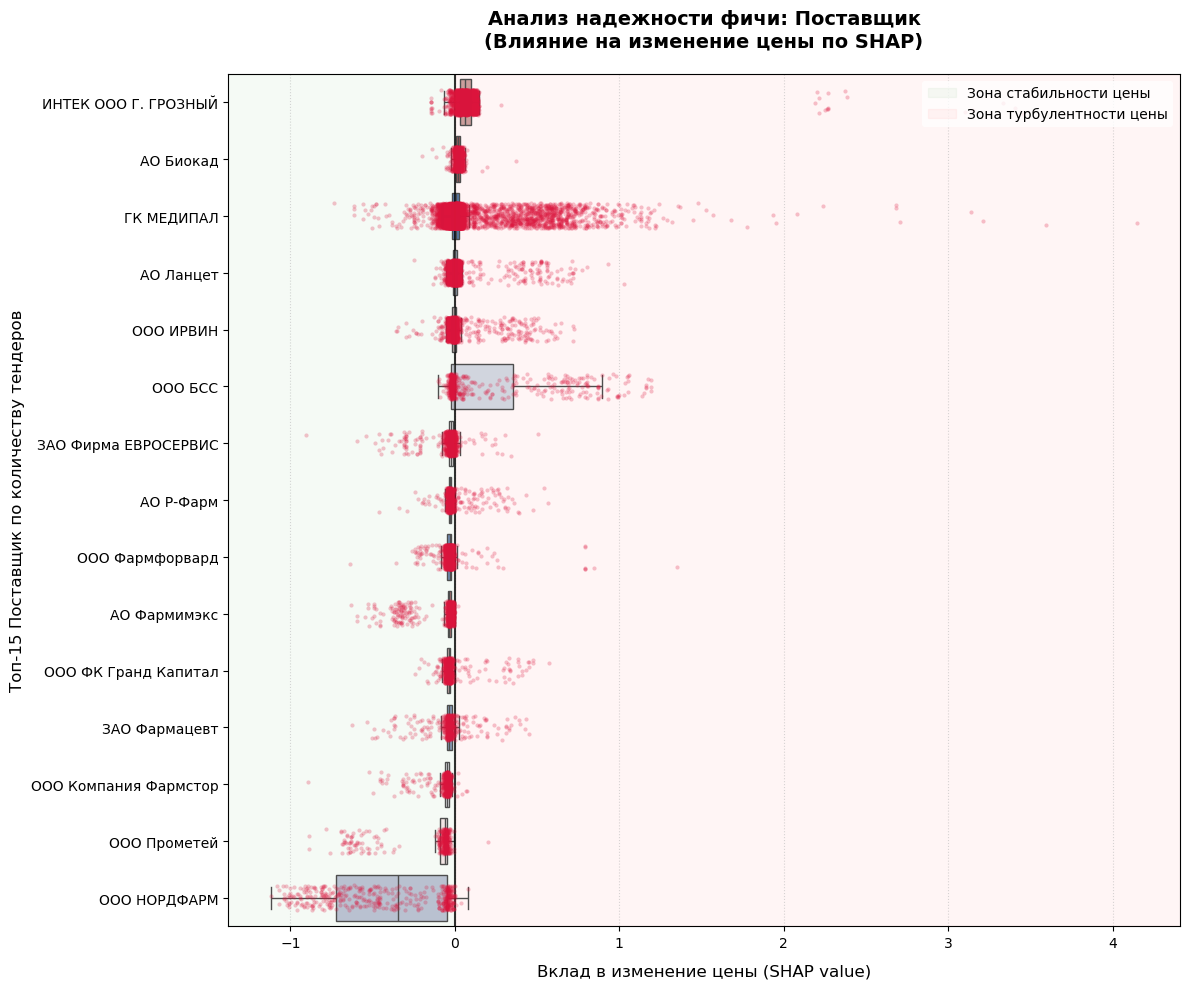

In [ ]:
# Как Поставщик влияет на изменение цены?
snap_graph(
    df=df,
    column='Поставщик',
    shap_values_matrix=shap_values, # матрица SHAP (обычно n_samples x n_features)
    feature_names=X.columns
)

Обучим модель регрессии на прогнозирование изменения цены. Это будет базовая линия для отсчета.

Количество участников тендера (самый значимый показатель по влиянию на изменение цены в торгах) нам заранее неизвестно, поэтому не можем его включить как фичу в модель.

Метрика МАЕ остается актуальной для нашего типа данных, где более 75% случаев имеет нулевое изменение цены.

Фичи выбираем ориентируясь на долю вклада фичей из предварительно обученной на полном датасете модели CatBoostRegressor, чтобы они были больше едниницы.

In [ ]:
# списки категориальных и числовых признаков
categorical_features = [
     'МНН', # вклад в формирование тергета 8.6
     'Форма', # вклад 7.6
     'Наименование', # вклад 6.2
     'Поставщик', # вклад 4.9
     'ФО', # вклад 3.7
     'Регион' # вклад 3.3

]

numerical_features = [
    'PricePack_contr', # вклад 6.1
    'TenderMonth', # вклад 5.9
    'КвоСпецЛота', # вклад 4.1
    'КвоКонтракт', # вклад 3.0
    'TenderYear', # вклад 1.3
    'СуммаКонтракт' # вклад 1.5
]

features_to_use = categorical_features + numerical_features

# выделяем X и y
X = df[features_to_use].copy()
y = df['ИзменениеЦены']

# приводим категории к строкам
for col in categorical_features:
    X[col] = X[col].astype(str)

# train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pool (указывая текстовые категории) для модели
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
val_pool = Pool(X_val, y_val, cat_features=categorical_features)

# обучаем модель CatBoost на трейне с валидацией по критерию минимизации MAE
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50 # Остановит обучение, если MAE на валидации начнет расти
)


0:	learn: 1.4229615	test: 1.4462277	best: 1.4462277 (0)	total: 56.2ms	remaining: 28s
100:	learn: 1.3394245	test: 1.3463026	best: 1.3463026 (100)	total: 4.72s	remaining: 18.7s
200:	learn: 1.3067724	test: 1.3178524	best: 1.3178524 (200)	total: 9.46s	remaining: 14.1s
300:	learn: 1.2842047	test: 1.3062196	best: 1.3061600 (295)	total: 14.3s	remaining: 9.42s
400:	learn: 1.2685589	test: 1.2967346	best: 1.2967301 (399)	total: 20.1s	remaining: 4.96s
499:	learn: 1.2590057	test: 1.2911800	best: 1.2911800 (499)	total: 26.7s	remaining: 0us

bestTest = 1.291180031
bestIteration = 499



Двухэтапная модель:
Классификатор (CatBoostClassifier) обучается на всех данных предсказывать, изменится ли цена вообще (y != 0).
Регрессор (CatBoostRegressor) обучается только на тех сделках, где цена действительно изменилась (таргет не равен 0). Это позволяет ему лучше настроиться на «хвосты» и величину аномалий, не отвлекаясь на константные нули.
Объединение: На валидации мы сначала отсекаем нули классификатором, а для остальных позиций берем прогноз регрессора, после чего считаем итоговый MAE.

Порог значимости вероятности ( при какой вероятности считать что цена изменится) бедм перебирать циклом от 0.1 до 0.95 с шагом 0.1 с критерием минимума МАЕ

In [ ]:
# фичи будут те же что и на базовой модели

X = df[features_to_use].copy()
y = df["ИзменениеЦены"]

for col in categorical_features:
    X[col] = X[col].astype(str)

# Разбиение на train/val (строго на тех же условиях и random_state)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# бинарный таргет для классификации (1 — цена изменилась, 0 — осталась прежней)
y_train_class = (y_train != 0).astype(int)
y_val_class = (y_val != 0).astype(int)



# ЭТАП 1: ОБУЧЕНИЕ КЛАССИФИКАТОРА

print("--- Шаг 1: Обучение классификатора (Факт изменения цены) ---")
clf_train_pool_orig = Pool(X_train, y_train_class, cat_features=categorical_features)
clf_val_pool_orig = Pool(X_val, y_val_class, cat_features=categorical_features)

clf_model_orig = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    loss_function="Logloss",  # Оптимизируем классическую бинарную кросс-энтропию
    random_seed=42,
    verbose=100,
)

clf_model_orig.fit(
    clf_train_pool_orig, eval_set=clf_val_pool_orig, early_stopping_rounds=50
)



# ЭТАП 2: ОБУЧЕНИЕ РЕГРЕССОРА (Только на ненулевых объектах)

print("\n--- Шаг 2: Обучение регрессора (Величина изменения цены) ---")

# Фильтруем ТРЕЙН — оставляем только ненулевые
mask_train_nonzero = y_train != 0
X_train_reg = X_train[mask_train_nonzero]
y_train_reg = y_train[mask_train_nonzero]

# Фильтруем ВАЛИДАЦИЮ — тоже оставляем только ненулевые
mask_val_nonzero = y_val != 0
X_val_reg = X_val[mask_val_nonzero]
y_val_reg = y_val[mask_val_nonzero]

reg_train_pool = Pool(X_train_reg, y_train_reg, cat_features=categorical_features)
reg_val_pool = Pool(X_val_reg, y_val_reg, cat_features=categorical_features)

reg_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

# модель регрессии обучится на ненулевых случаях изменения цены
reg_model.fit(
    reg_train_pool,
    eval_set=reg_val_pool,
    early_stopping_rounds=50
)



# ЭТАП 3: ОПТИМИЗАЦИЯ ПОРОГА И СБОРКА ПРОГНОЗА

print("\n--- Шаг 3: Оптимизация порога классификатора ---")

# Получаем вероятности того, что цена изменится (класс 1)
clf_preds_proba = clf_model_orig.predict_proba(X_val)[:, 1]

# Получаем чистый прогноз регрессора
reg_preds = reg_model.predict(X_val)

best_mae = float('inf')
# лучшим назначаем порог вероятности 50%
best_threshold = 0.5

# Перебираем пороги от 0.10 до 0.90 с шагом 0.05
for threshold in np.arange(0.1, 0.95, 0.05):
    # Если вероятность выше порога -> берем прогноз регрессора, иначе -> 0.0
    clf_preds_binary = (clf_preds_proba > threshold).astype(int)
    current_preds = np.where(clf_preds_binary == 1, reg_preds, 0.0)

    # Считаем MAE для текущего порога
    current_mae = mean_absolute_error(y_val, current_preds)
    print(f"Порог: {threshold:.2f} | Итоговый MAE: {current_mae:.5f}")

    # Фиксируем лучший результат
    if current_mae < best_mae:
        best_mae = current_mae
        best_threshold = threshold

print("\n" + "="*40)
print(f"ОПТИМАЛЬНЫЙ ПОРОГ: {best_threshold:.2f}")
print(f"МИНИМАЛЬНЫЙ MAE: {best_mae:.5f}")
print("="*40)

# 3. Финальный прогноз на основе лучшего порога
final_preds = np.where((clf_preds_proba > best_threshold).astype(int) == 1, reg_preds, 0.0)



--- Шаг 1: Обучение классификатора (Факт изменения цены) ---
0:	learn: 0.6215012	test: 0.6220108	best: 0.6220108 (0)	total: 87.6ms	remaining: 43.7s
100:	learn: 0.2766440	test: 0.2792533	best: 0.2792533 (100)	total: 6.14s	remaining: 24.2s
200:	learn: 0.2538802	test: 0.2664550	best: 0.2664550 (200)	total: 12.5s	remaining: 18.5s
300:	learn: 0.2366827	test: 0.2596376	best: 0.2595592 (296)	total: 21.4s	remaining: 14.1s
400:	learn: 0.2226078	test: 0.2543250	best: 0.2543250 (400)	total: 33s	remaining: 8.16s
499:	learn: 0.2123397	test: 0.2508312	best: 0.2508312 (499)	total: 43.1s	remaining: 0us

bestTest = 0.2508312124
bestIteration = 499


--- Шаг 2: Обучение регрессора (Величина изменения цены) ---
0:	learn: 7.3640056	test: 7.3124423	best: 7.3124423 (0)	total: 51.9ms	remaining: 25.9s
100:	learn: 5.3103141	test: 5.6680065	best: 5.6679139 (99)	total: 4.57s	remaining: 18.1s
200:	learn: 4.7936637	test: 5.4255647	best: 5.4255647 (200)	total: 9.14s	remaining: 13.6s
300:	learn: 4.4997722	test: 5.33

В результате применения комбинированной (классификатор + регрессор) модели удалось снизить ошибку МАЕ с  1.29 до 1.16

In [ ]:
def evaluate_classification_model(model, val_pool, model_name: str) -> pd.DataFrame:
    """
    Рассчитывает метрики классификации, выводит отчет в консоль
    и возвращает DataFrame с результатами.
    """
    # Получаем предсказания классов
    y_pred = model.predict(val_pool)

    # Извлекаем истинные ответы
    y_true = val_pool.get_label()

    # Расчет метрик
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Вывод результатов в консоль
    print("--- Основные метрики классификации ---")
    print(f"Accuracy (Доля правильных ответов): {accuracy:.4f}")
    print(f"Precision (Точность):              {precision:.4f}")
    print(f"Recall (Полнота):                  {recall:.4f}")
    print(f"F1-Score:                          {f1:.4f}")
    print("\n--- Подробный отчет (Classification Report) ---")
    print(classification_report(y_true, y_pred))

    # Формирование итогового DataFrame
    metrics_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Value': [accuracy, precision, recall, f1],
        'Model': model_name
    }

    return pd.DataFrame(metrics_data)


In [ ]:
df_metrics_1 = evaluate_classification_model(
    model=clf_model_orig,
    val_pool=clf_val_pool_orig,
    model_name="Двухэтапная модель с оригинальными фичами"
)

--- Основные метрики классификации ---
Accuracy (Доля правильных ответов): 0.8937
Precision (Точность):              0.7711
Recall (Полнота):                  0.5445
F1-Score:                          0.6383

--- Подробный отчет (Classification Report) ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      5232
           1       0.77      0.54      0.64      1089

    accuracy                           0.89      6321
   macro avg       0.84      0.76      0.79      6321
weighted avg       0.89      0.89      0.89      6321



In [ ]:
def plot_actual_vs_predicted(clf_model, reg_model, X_val, y_val, threshold):
    """Строит график рассеяния 'Прогноз — Факт' для двухэтапной комбинированной модели.

    Параметры:
    clf_model: обученный CatBoostClassifier (Шаг 1)
    reg_model: обученный CatBoostRegressor (Шаг 2)
    X_val: валидационные признаки (DataFrame)
    y_val: фактические значения изменения цены (Series или array)
    threshold: порог отсечки классификатора (float от 0 до 1)
    """
    # 1. Получаем вероятности от классификатора и предсказания регрессора
    clf_preds_proba = clf_model.predict_proba(X_val)[:, 1]
    reg_preds = reg_model.predict(X_val)

    # 2. Формируем итоговый прогноз комбинированной модели на основе переданного порога
    y_pred = np.where(clf_preds_proba > threshold, reg_preds, 0.0)
    y_true = np.array(y_val)

    # 3. Находим общие границы для линии идеального прогноза
    lims = [
        min(min(y_true), min(y_pred)),
        max(max(y_true), max(y_pred)),
    ]

    # 4. Визуализация
    plt.figure(figsize=(10, 8))

    # Рисуем точки с прозрачностью alpha=0.2
    plt.scatter(
        y_true, y_pred, color="#1f77b4", alpha=0.2, edgecolors="none", s=25
    )

    # Линия идеального прогноза (Прогноз = Факт)
    plt.plot(
        lims,
        lims,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label="Идеальный прогноз (Факт = Прогноз)",
    )

    # Оформление графика с динамическим отображением порога в названиях
    plt.title(
        f"График Прогноз — Факт (Комбинированная модель)\nПорог классификатора: {threshold:.2f}",
        fontsize=14,
        pad=15,
        fontweight="bold",
    )
    plt.xlabel("Фактическое ИзменениеЦены (Данные торгов)", fontsize=12)
    plt.ylabel(f"Прогноз модели (Порог {threshold:.2f})", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

    # Создаем датафрейм для анализа ошибок
    error_df = X_val.copy()
    error_df['True_Value'] = y_true
    error_df['Predicted_Value'] = y_pred
    error_df['Absolute_Error'] = np.abs(y_true - y_pred)

    # Отбираем топ-10 строк с самой большой абсолютной ошибкой
    top_discrepancies = error_df.sort_values(by='Absolute_Error', ascending=False).head(10)

    # Выводим ключевые колонки для анализа
    print("=== ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК МОДЕЛИ ===")
    print(top_discrepancies[['Наименование', 'Поставщик', 'True_Value', 'Predicted_Value', 'Absolute_Error']])


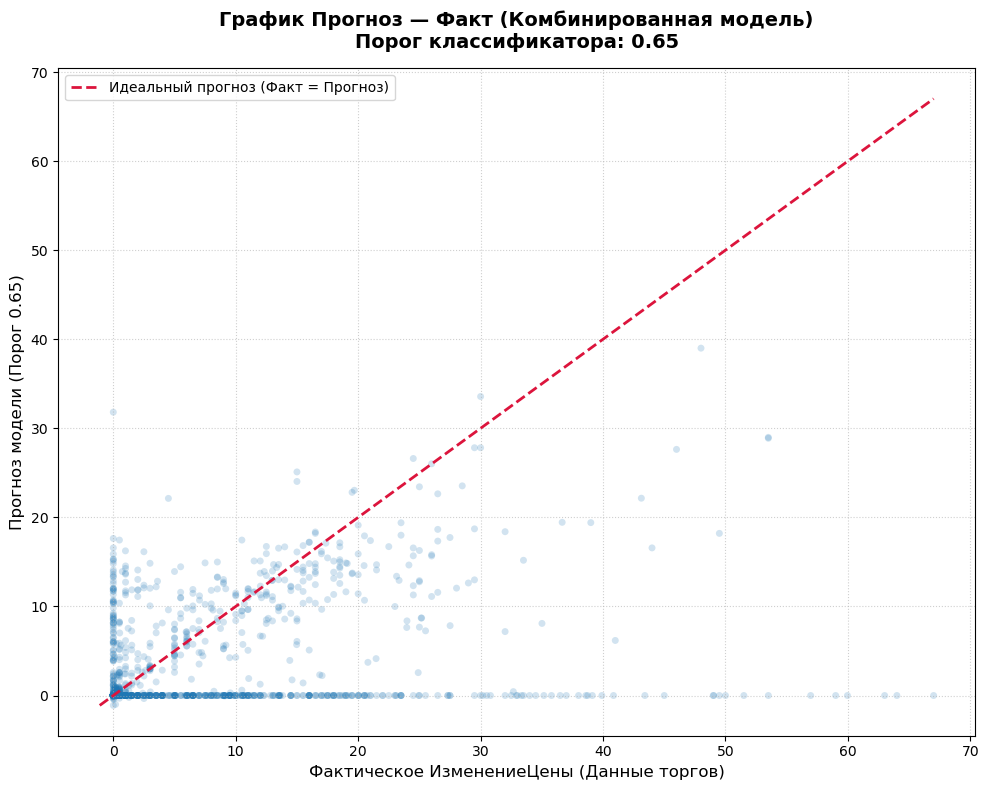

=== ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК МОДЕЛИ ===
                             Наименование  \
3564                             ГАДОВИСТ   
10639                            ГАДОВИСТ   
3575                             ГАДОВИСТ   
14641                            СТИВАРГА   
6110                        ИМБИОГЛОБУЛИН   
247                                 ЭЙЛЕА   
11670                            ФИРИАЛТА   
15051                            АЛЬБУМИН   
19945                            ГАДОВИСТ   
11012  ИММУНОГЛОБУЛИН ЧЕЛОВЕКА НОРМАЛЬНЫЙ   

                                  Поставщик  True_Value  Predicted_Value  \
3564                       ООО Фармкомплект   67.000000              0.0   
10639                  ООО ФК Гранд Капитал   64.000099              0.0   
3575                       ООО Фармкомплект   63.000000              0.0   
14641           ФАРМСЕРВИС ООО Г. КРАСНОДАР   59.961700              0.0   
6110                             ГК МЕДИПАЛ   59.000000              0.0   
247  

In [ ]:
# визуал отклонения факта от прогноза на модел с оригинальными фичами с выводом топ-10 ошибок
plot_actual_vs_predicted(clf_model_orig, reg_model, X_val, y_val, threshold=best_threshold)

В списке доминируют три группы препаратов: Препараты крови и иммуноглобулины (Иммуноглобулин человека нормальный, Альбумин человеческий, Имбиоглобулин).Контрастные вещества для МРТ (Гадовист, Магневист).

Почему классификатор их пропустил?

Препараты крови и контрасты потеряли патентную монополию на торгах сталкиваются оригинальные импортные препараты и их более дешевые копии, что провоцирует конкуренцию по цене.

Добавим новые признаки для модели:

Item_Unstability_Rate (Статистический): Доля случаев изменения цены по конкретному товару, рассчитанная на исторических данных X_train.

Days_Since_Last_Tender (Временной): Сколько дней прошло с момента предыдущего тендера по этому же Наименованию. Этот признак ловит частоту закупок и дефицит на рынке.

Year_Trend_Interaction (Временной): Произведение года и месяца для фиксации линейного тренда инфляции.

Количество аналогов препарата (групповых и полных)

In [ ]:
# считываю данные о наличии аналогов для каждого наименования и считаю их количество
analogs = pd.read_csv('Аналоги.csv')
analogs = analogs.pivot_table(
    index='ТН',
    columns='Тип_аналога',
    values='АТХ_аналог',
    aggfunc='count',
    fill_value=0
).astype(int).rename_axis(None, axis=1).reset_index().rename(columns = {'ТН':'Наименование'})

analogs.head(3)

,Наименование,Групповой,Полный
0,5-НОК,68,2
1,5-ФТОРУРАЦИЛ-ЭБЕВЕ,61,6
2,IGE-АТ-ИФТС,159,0


In [ ]:
print("--- Шаг 1: Базовая подготовка данных ---")

# исходный датафрейм, с дополнительной информацией об аналогах Полных и Групповых
df_processed = df.merge(analogs, on = ['Наименование'], how = 'left').fillna(0)

# Приводим дату к формату datetime для расчета временных интервалов
df_processed['TendDt'] = pd.to_datetime(df_processed['TendDt'])

# Сортируем данные по дате, чтобы корректно считать "предыдущие" тендеры
df_processed = df_processed.sort_values(by='TendDt').reset_index(drop=True)

# Списки базовых признаков категориальные -  без изменений, к числовым добавим количество аналогов наименования
numerical_features_ext = numerical_features + ['Групповой'] + ['Полный']


# Разделяем на train и val (80/20).
# Используем random_state=42 для честного сравнения с прошлыми результатами
df_train, df_val = train_test_split(df_processed, test_size=0.2, random_state=42)



print("--- Шаг 2: Генерация дополнительных  признаков ---")

def generate_advanced_features(target_df, source_train_df):
    """
    Генерирует признаки для целевого датафрейма.
    Статистика (Unstability) и временные лаги берутся на основе обучающей выборки (source_train_df),
    чтобы полностью исключить заглядывание в будущее на валидации.
    """
    df_out = target_df.copy()


    # Временной признак: Взаимодействие года и месяца (тренд инфляции)
    df_out['Year_Trend_Interaction'] = df_out['TenderYear'] * df_out['TenderMonth']

    # Статистический признак: Частота изменения цен товаров (Item_Unstability_Rate)
    # Считается строго по source_train_df!
    unstability_stats = (
        source_train_df.groupby("Наименование")["ИзменениеЦены"]
        .apply(lambda x: (x != 0).mean())
        .reset_index()
    )
    unstability_stats.columns = ["Наименование", "Item_Unstability_Rate"]
    df_out = df_out.merge(unstability_stats, on="Наименование", how="left")
    df_out["Item_Unstability_Rate"] = df_out["Item_Unstability_Rate"].fillna(0.0)

    # Временной признак: Дней с момента прошлого тендера по этому товару
    # Находим последнюю известную дату тендера для каждого товара в обучающей выборке
    last_tender_dates = source_train_df.groupby('Наименование')['TendDt'].max().reset_index()
    last_tender_dates.columns = ['Наименование', 'Last_TendDt']

    df_out = df_out.merge(last_tender_dates, on='Наименование', how='left')

    # Считаем разницу в днях между текущим тендером и предыдущим известным из трейна
    df_out['Days_Since_Last_Tender'] = (df_out['TendDt'] - df_out['Last_TendDt']).dt.days

    # Если товар новый или это самый первый тендер, заполняем пропуск "заглушкой" -1
    df_out['Days_Since_Last_Tender'] = df_out['Days_Since_Last_Tender'].fillna(-1.0)

    # Удаляем временную колонку даты, чтобы она не пошла в модель
    df_out = df_out.drop(columns=['Last_TendDt'])

    return df_out

# Применяем функцию генерации признаков отдельно к Train и Val выборкам
df_train_extended = generate_advanced_features(df_train, df_train)
df_val_extended = generate_advanced_features(df_val, df_train)

# Обновляем итоговый список числовых признаков для модели
new_numerical_features = [
    "Year_Trend_Interaction",
    "Item_Unstability_Rate",
    "Days_Since_Last_Tender"
]

# расширенные фичи модели - категориальные (без изменений) + числовые (с добавлением аналогов) + числовые (расчетные)
features_to_use_ext = categorical_features + numerical_features_ext + new_numerical_features

# Выделяем финальные матрицы признаков и таргеты
X_train = df_train_extended[features_to_use_ext]
y_train = df_train_extended["ИзменениеЦены"]

X_val = df_val_extended[features_to_use_ext]
y_val = df_val_extended["ИзменениеЦены"]

# Бинарные таргеты для Классификатора
y_train_class = (y_train != 0).astype(int)
y_val_class = (y_val != 0).astype(int)


print("\n--- Шаг 3: Обучение классификатора (Новый пул признаков) ---")
clf_train_pool_ext = Pool(X_train, y_train_class, cat_features=categorical_features)
clf_val_pool_ext = Pool(X_val, y_val_class, cat_features=categorical_features)

clf_model_ext = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    # auto_class_weights='Balanced', # автобалансировка классов
    class_weights=[1, 3],
    loss_function="Logloss",
    random_seed=42,
    verbose=100,
)
clf_model_ext.fit(clf_train_pool_ext, eval_set=clf_val_pool_ext, early_stopping_rounds=50)



print("\n--- Шаг 4: Плавное обучение регрессора (Новый пул признаков) ---")
mask_train_nonzero = y_train != 0
X_train_reg = X_train[mask_train_nonzero]
y_train_reg = y_train[mask_train_nonzero]

mask_val_nonzero = y_val != 0
X_val_reg = X_val[mask_val_nonzero]
y_val_reg = y_val[mask_val_nonzero]

reg_train_pool = Pool(X_train_reg, y_train_reg, cat_features=categorical_features)
reg_val_pool = Pool(X_val_reg, y_val_reg, cat_features=categorical_features)

reg_model = CatBoostRegressor(
    iterations=1000,          # Даем модели 1000 шагов для глубокого анализа лагов
    learning_rate=0.05,       # Низкий шаг защитит от финансовых выбросов (крупных сумм)
    loss_function="MAE",
    random_seed=42,
    verbose=100,
)
reg_model.fit(reg_train_pool, eval_set=reg_val_pool, early_stopping_rounds=50)



print("\n--- Шаг 5: Оптимизация порога и сборка финального прогноза ---")
clf_preds_proba = clf_model_ext.predict_proba(X_val)[:, 1]
reg_preds = reg_model.predict(X_val)

best_mae = float("inf")
best_threshold = 0.5

for threshold in np.arange(0.1, 0.95, 0.05):
    clf_preds_binary = (clf_preds_proba > threshold).astype(int)
    current_preds = np.where(clf_preds_binary == 1, reg_preds, 0.0)
    current_mae = mean_absolute_error(y_val, current_preds)
    print(f"Порог: {threshold:.2f} | Итоговый MAE: {current_mae:.5f}")

    if current_mae < best_mae:
        best_mae = current_mae
        best_threshold = threshold

print("\n" + "=" * 50)
print(f"ФИНАЛЬНЫЙ ОПТИМАЛЬНЫЙ ПОРОГ ПАЙПЛАЙНА: {best_threshold:.2f}")
print(f"АБСОЛЮТНЫЙ МИНИМУМ MAE С НОВЫМИ ПРИЗНАКАМИ: {best_mae:.5f}")
print("=" * 50)


--- Шаг 1: Базовая подготовка данных ---
--- Шаг 2: Генерация дополнительных  признаков ---

--- Шаг 3: Обучение классификатора (Новый пул признаков) ---
0:	learn: 0.6566658	test: 0.6572511	best: 0.6572511 (0)	total: 61.5ms	remaining: 30.7s
100:	learn: 0.3678272	test: 0.3694577	best: 0.3694577 (100)	total: 6.29s	remaining: 24.9s
200:	learn: 0.3237761	test: 0.3479797	best: 0.3479797 (200)	total: 12.7s	remaining: 18.9s
300:	learn: 0.2967774	test: 0.3388329	best: 0.3388329 (300)	total: 19.2s	remaining: 12.7s
400:	learn: 0.2756134	test: 0.3336726	best: 0.3334701 (399)	total: 27.1s	remaining: 6.68s
499:	learn: 0.2568471	test: 0.3304679	best: 0.3300933 (495)	total: 35.9s	remaining: 0us

bestTest = 0.3300932504
bestIteration = 495

Shrink model to first 496 iterations.

--- Шаг 4: Плавное обучение регрессора (Новый пул признаков) ---
0:	learn: 7.4194650	test: 7.6631800	best: 7.6631800 (0)	total: 42.5ms	remaining: 42.4s
100:	learn: 5.6691490	test: 5.9350196	best: 5.9350196 (100)	total: 4.49s	r

Добавление новых признаков еще снизило метрику. Абсолютный минимум MAE опустился с 1.16 до 1.15 при оптимальном пороге значимости 0.80.

In [ ]:
# метрики классификации на модели с дополненными фичами
df_metrics_2 = evaluate_classification_model(
    model=clf_model_ext,
    val_pool=clf_val_pool_ext,
    model_name="Двухэтапная модель с дополненными фичами"
)

--- Основные метрики классификации ---
Accuracy (Доля правильных ответов): 0.8722
Precision (Точность):              0.5849
Recall (Полнота):                  0.7964
F1-Score:                          0.6745

--- Подробный отчет (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      5270
           1       0.58      0.80      0.67      1051

    accuracy                           0.87      6321
   macro avg       0.77      0.84      0.80      6321
weighted avg       0.89      0.87      0.88      6321



In [ ]:
# сравниваем метрики модели классификации на оригинальных и дополненных фичах
df_merged = df_metrics_2.merge(df_metrics_1, on = ['Metric'])
df_metrics = df_merged[['Metric', 'Value_x', 'Value_y']].copy()

df_metrics.columns = [
    'Метрика',
    'Двухэтапная модель с дополненными фичами',
    'Двухэтапная модель с оригинальными фичами'
]

# Считаем разницу, чтобы сразу видеть, какая модель лучше
df_metrics['Разница (Дополненные - Оригинальные)'] = (
    df_metrics['Двухэтапная модель с дополненными фичами'] -
    df_metrics['Двухэтапная модель с оригинальными фичами']
)

df_metrics

,Метрика,Двухэтапная модель с дополненными фичами,Двухэтапная модель с оригинальными фичами,Разница (Дополненные - Оригинальные)
0,Accuracy,0.872172,0.893688,-0.021516
1,Precision,0.584906,0.771131,-0.186226
2,Recall,0.796384,0.544536,0.251848
3,F1-Score,0.674456,0.638321,0.036135


Новая модель с дополненными фичами и акцентом на поиск турбулетности цены в тендере стала более активной в поиске целевого класса и находит 79% таких случаев, заплатив за это - увеличением числа ложных срабатываний, точность снизилась с 77% до 58%.
Выбираем вторую модель так как цена пропуска изменения цены высока, лучше знать ее заранее, пусть даже это будет ложная тревога.

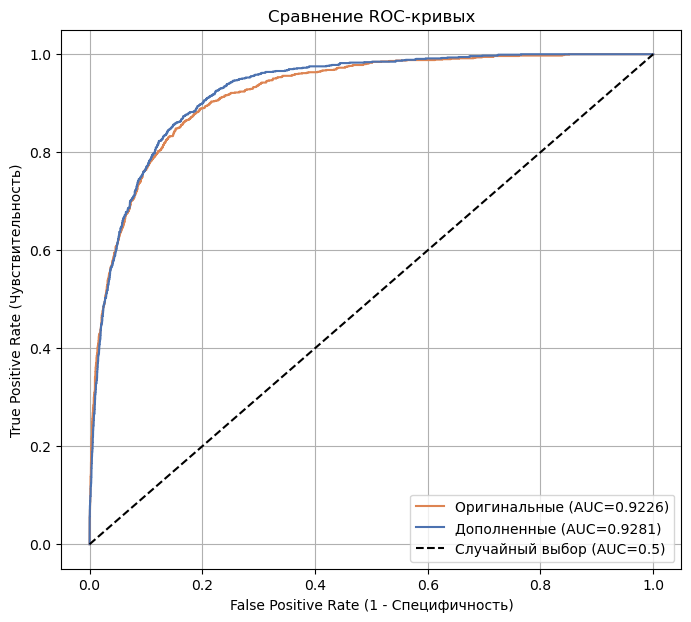

In [ ]:
# сравним ROC кривые классификатора на оригинальных и на дополненных фичах
# увидим разницу предсказаний вероятности изменения цены в торгах при разных порогах

# Получение данных и вероятностей
y_true_orig = clf_val_pool_orig.get_label()
y_true_ext = clf_val_pool_ext.get_label()
y_proba_orig = clf_model_orig.predict_proba(clf_val_pool_orig)[:, 1]
y_proba_ext = clf_model_ext.predict_proba(clf_val_pool_ext)[:, 1]

# Расчет AUC и точек ROC-кривой
auc_orig = roc_auc_score(y_true_orig, y_proba_orig)
auc_ext = roc_auc_score(y_true_ext, y_proba_ext)
fpr_orig, tpr_orig, _ = get_roc_curve(clf_model_orig, clf_val_pool_orig)
fpr_ext, tpr_ext, _ = get_roc_curve(clf_model_ext, clf_val_pool_ext)

# Отрисовка
plt.figure(figsize=(8, 7))
plt.plot(fpr_orig, tpr_orig, label=f'Оригинальные (AUC={auc_orig:.4f})', color='#DD8452')
plt.plot(fpr_ext, tpr_ext, label=f'Дополненные (AUC={auc_ext:.4f})', color='#4C72B0')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный выбор (AUC=0.5)')
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('Сравнение ROC-кривых')
plt.legend()
plt.grid(True)
plt.show()


ROC-кривая отражает способность модели ранжировать объекты: способность присваивать истинно положительным классам более высокую вероятность, чем истинно отрицательным. Раз она однозначно улучшилась, это фундаментально доказывает, что новая модель лучше разделяет классы. В ней стало меньше хаоса и пересечений между распределениями вероятностей для классов

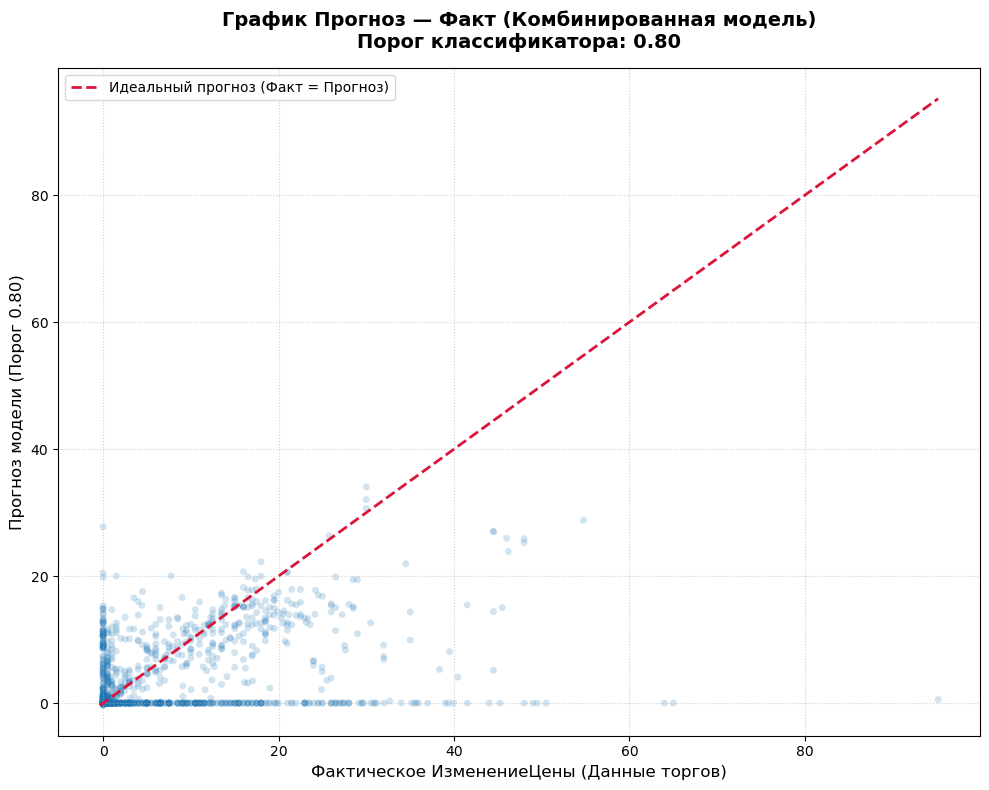

=== ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК МОДЕЛИ ===
                            Наименование             Поставщик  True_Value  \
4711  ИММУНОГЛОБУЛИН ЧЕЛОВЕКА НОРМАЛЬНЫЙ            ГК МЕДИПАЛ   95.191597   
3993                           МАГНЕВИСТ  ООО ФК Гранд Капитал   65.000000   
948                             ГАДОВИСТ  ООО ФК Гранд Капитал   64.000099   
1618                            ГАДОВИСТ             АО Ланцет   50.500702   
6157  ИММУНОГЛОБУЛИН ЧЕЛОВЕКА НОРМАЛЬНЫЙ            ГК МЕДИПАЛ   49.500000   
716                             ГАДОВИСТ             ООО ИРВИН   49.000000   
3528                            ГАДОВИСТ  ЗАО ФИРМА ЕВРОСЕРВИС   48.000000   
3276                           РЕЗОГАМ Н            ГК МЕДИПАЛ   45.218899   
4856                           МАЛЬТОФЕР      ООО Надежда-Фарм   43.999901   
1113                           ПРИВИДЖЕН            ГК МЕДИПАЛ   41.523602   

      Predicted_Value  Absolute_Error  
4711         0.552168       94.639429  
3993         0.000

In [ ]:
# визуал факт-прогноз последней модели и вывод топ_10 ошибок
plot_actual_vs_predicted(clf_model_ext, reg_model, X_val, y_val, threshold=best_threshold)

Какими стали веса фичей с учетом введения новых признаков?

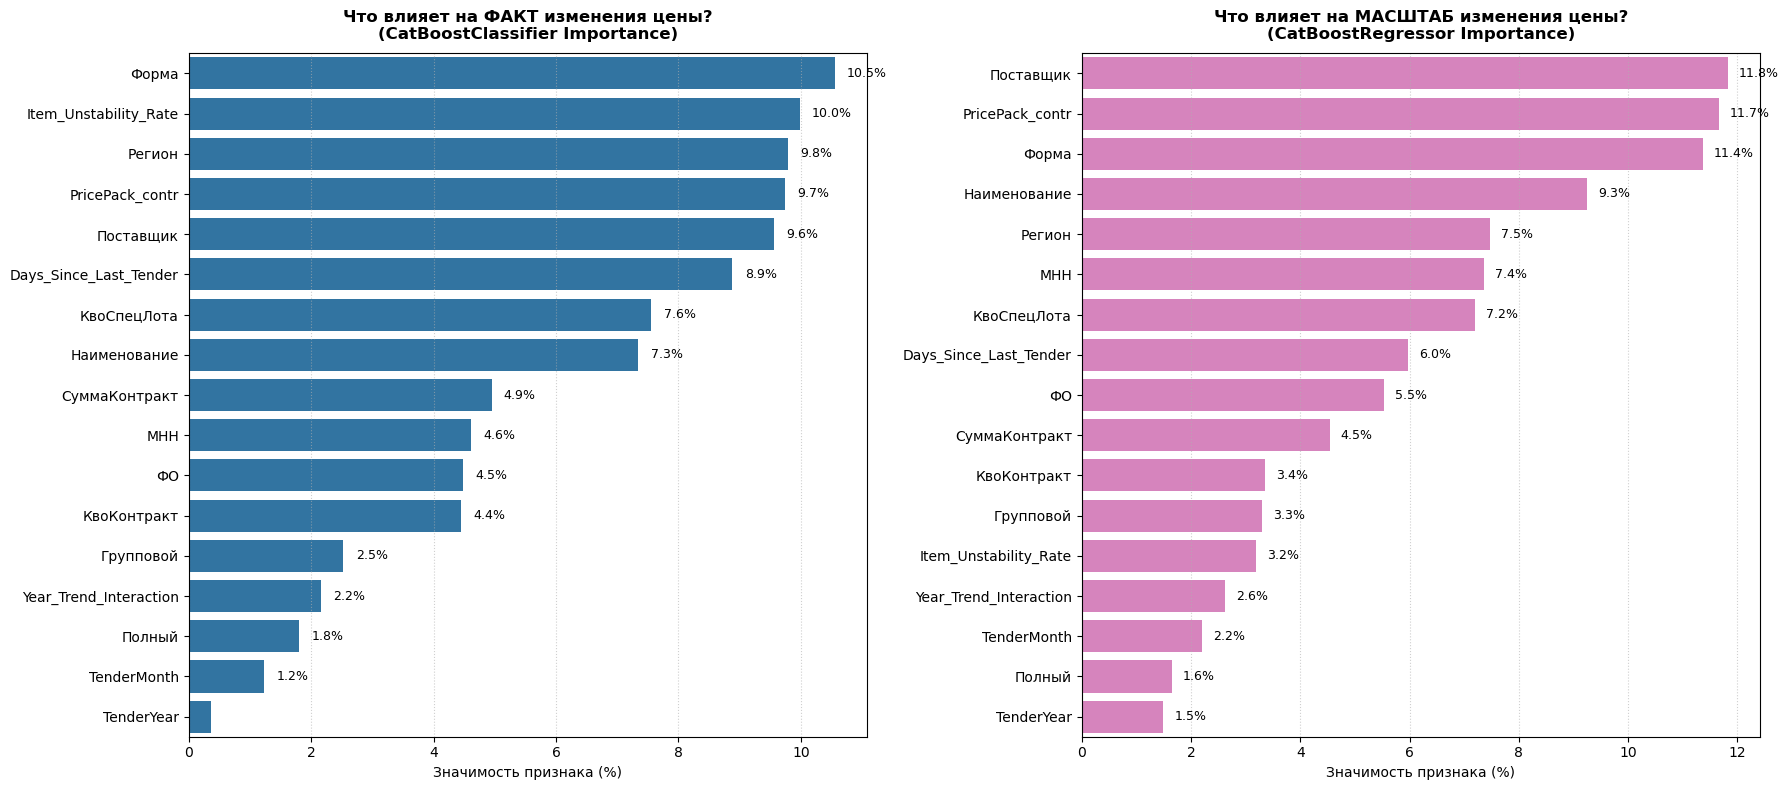

In [ ]:
def plot_feature_importance(model, feature_names, title, ax, color):
    """Вспомогательная функция для отрисовки топ-важности признаков для каждй из моделей по отдельности."""
    # Получаем веса от CatBoost
    importances = model.get_feature_importance()

    # Создаем датафрейм и сортируем по убыванию
    feat_imp_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": importances}
    ).sort_values(by="Importance", ascending=False)

    # Строим горизонтальный бар-чарт
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feat_imp_df,
        ax=ax,
        color=color,
        edgecolor="none",
    )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Значимость признака (%)", fontsize=10)
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle=":", alpha=0.6)

    # Добавляем текстовые значения процентов на бары для scannability
    for p in ax.patches:
        width = p.get_width()
        if width > 0.5:  # Выводим только значимые цифры
            ax.text(
                width + 0.2,
                p.get_y() + p.get_height() / 2,
                f"{width:.1f}%",
                va="center",
                ha="left",
                fontsize=9,
            )


# Создаем общее поле для двух графиков
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# 1. График для классификатора
plot_feature_importance(
    model=clf_model_ext,
    feature_names=features_to_use_ext,
    title='Что влияет на ФАКТ изменения цены?\n(CatBoostClassifier Importance)',
    ax=axes[0],
    color="#1f77b4",
)

# 2. График для регрессора
plot_feature_importance(
    model=reg_model,
    feature_names=features_to_use_ext,
    title='Что влияет на МАСШТАБ изменения цены?\n(CatBoostRegressor Importance)',
    ax=axes[1],
    color="#e377c2",
)

plt.tight_layout()
plt.show()


Видим что новые фичи оказались полезны модели классификации, для регрессии они на более низких позициях находятся

ДОЛЯ СДЕЛОК С ОШИБКОЙ МЕНЕЕ 0.5 ПРОЦЕНТНЫх ПУНКТОВ: 85.67%


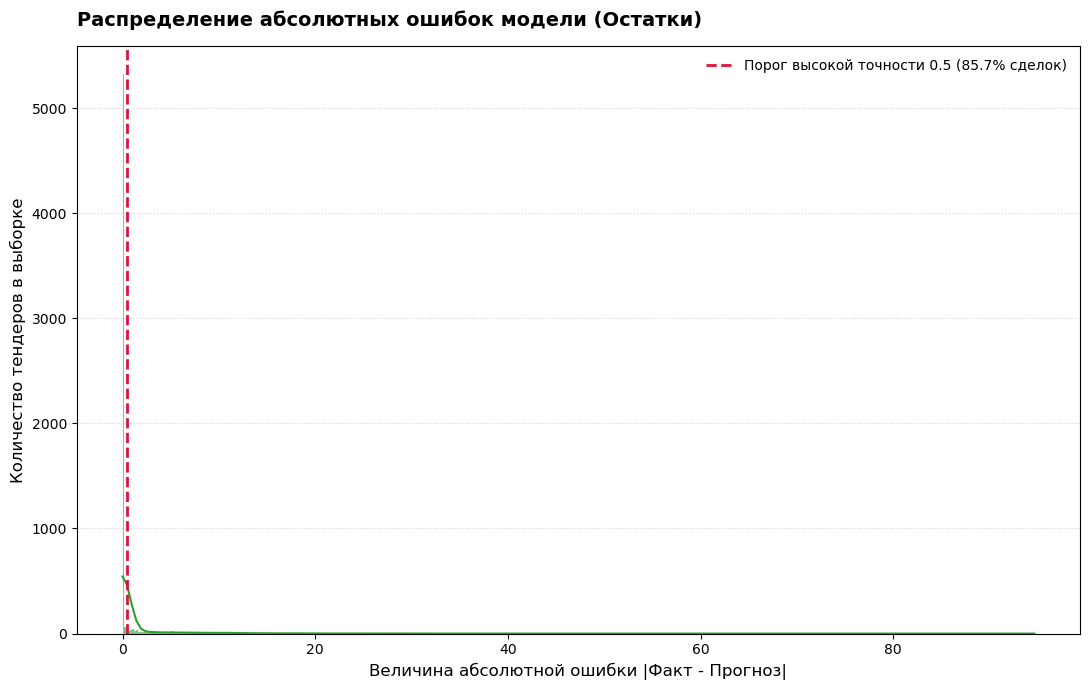

In [ ]:
# визуал остатков модели с расширенными фичами
# Получаем финальный комбинированный прогноз на валидационной выборке
clf_preds_proba = clf_model_ext.predict_proba(X_val)[:, 1]
reg_preds = reg_model.predict(X_val)
y_pred = np.where(clf_preds_proba > best_threshold, reg_preds, 0.0)
y_true = np.array(y_val)

# Абсолютная ошибка по каждой сделке
abs_errors = np.abs(y_true - y_pred)

# Считаем процент сделок с ошибкой менее 0.5
accurate_pct = (abs_errors < 0.5).mean() * 100

print("=" * 60)
print(f"ДОЛЯ СДЕЛОК С ОШИБКОЙ МЕНЕЕ 0.5 ПРОЦЕНТНЫх ПУНКТОВ: {accurate_pct:.2f}%")
print("=" * 60)


plt.figure(figsize=(11, 7))

# Строим гистограмму абсолютных ошибок
# Ограничим x_max значением 10, чтобы длинный хвост редких аномалий (до 95) не сжимал основной график
sns.histplot(
    abs_errors,
    bins=50,
    kde=True,
    color="#2ca02c",
    binrange=(0, 10),
    edgecolor="white",
    alpha=0.7,
)

# Вертикальная линия порога 0.5
plt.axvline(
    x=0.5,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Порог высокой точности 0.5 ({accurate_pct:.1f}% сделок)",
)

# Настройка графика
plt.title(
    "Распределение абсолютных ошибок модели (Остатки)",
    fontsize=14,
    pad=15,
    fontweight="bold",
    loc="left",
)
plt.xlabel("Величина абсолютной ошибки |Факт - Прогноз|", fontsize=12)
plt.ylabel("Количество тендеров в выборке", fontsize=12)
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()


ВТОРАЯ ЧАСТЬ ЗАДАЧИ - КЛАСТЕРИЗАЦИЯ ПОСТАЩИКОВ по динамике снижения Начальной Максимальной Цены тендера за полный календарный год

In [ ]:
# количество единиц в сделке не всегда указано,пересчитываем сходя из цены за единицу
df['КвоКонтракт'] = round(df['СуммаКонтракт']/df['PricePack_contr'],0)

# считаю взвешенное изменение на количество проданных единиц в агрегации до месяцев
df['Weighted_Value'] = df['ИзменениеЦены'] * df['КвоКонтракт']

group_columns = ['TenderYear', 'TenderMonth', 'Наименование', 'Поставщик']

df_month = df.groupby(group_columns).agg( КвоКонтракт =('КвоКонтракт', 'sum'),
                                          Total_Weighted=('Weighted_Value', 'sum')
                                         ).reset_index()

df_month['Изменение'] = round(df_month['Total_Weighted'] / df_month['КвоКонтракт'],2)

df_month = df_month.sort_values(by = ['Поставщик','Наименование','TenderYear', 'TenderMonth']).drop(columns=['Total_Weighted'])

print('Всего уникальных ТН:', df_month['Наименование'].nunique())
print('Всего уникальных Поставщиков', df_month['Поставщик'].nunique())

Всего уникальных ТН: 67
Всего уникальных Поставщиков 398


In [ ]:
# отбираем тех поставщиков и наименования у которых количество уникальных записей не менее 6 строк
# Фильтруем группы, где количество уникальных записей (месяцев) >= 6
df_filtr = df_month.groupby(['Наименование', 'Поставщик']).filter(lambda x: len(x) >= 6)

print('Осталось уникальных ТН:', df_filtr['Наименование'].nunique())
print('Осталось уникальных Поставщиков', df_filtr['Поставщик'].nunique())

Осталось уникальных ТН: 66
Осталось уникальных Поставщиков 104


In [ ]:
# делаем дату начала месяца из года и месяца, заполняем пропуски данных нулями чтобы получить ряды одной длины

# дата начала месяца
df_filtr['Дата'] = pd.to_datetime(df_filtr['TenderYear'].astype(str) + '-' + df_filtr['TenderMonth'].astype(str) + '-01')

# генерируем полный диапазон месяцев на основе ваших данных
all_months = pd.date_range(start=df_filtr['Дата'].min(), end=df_filtr['Дата'].max(), freq="MS")

# находим только СУЩЕСТВУЮЩИЕ пары (Наименование, Поставщик)
pairs = df_filtr[['Наименование', 'Поставщик']].drop_duplicates()

# строим правильную сетку календаря ТОЛЬКО для существующих пар
full_index = pd.MultiIndex.from_frame(
    pairs.loc[pairs.index.repeat(len(all_months))]
)
# добавляем даты третьим уровнем в индекс
full_index = pd.MultiIndex.from_arrays([
    full_index.get_level_values(0),
    full_index.get_level_values(1),
    list(all_months) * len(pairs)
], names=['Наименование', 'Поставщик', 'Дата'])

# переиндексируем исходную таблицу и заполняем пустоты нулями
df_filled = (df_filtr.set_index(['Наименование', 'Поставщик', 'Дата'])
             .reindex(full_index, fill_value=0)
             .reset_index())

# обновляем колонки Года и Месяца на основе созданной даты
df_filled['TenderYear'] = df_filled['Дата'].dt.year
df_filled['TenderMonth'] = df_filled['Дата'].dt.month

In [ ]:
# сравним динамику изменения цен в тендерах по разным поставщикам
# нужны временные рядо по всем поставщикоам, название поставщика должно быть столбцом, дата индексом строки
time_s = pd.pivot_table(df_filled[['Дата','Поставщик','Изменение']],
                        index = ['Дата'],
                        columns = ['Поставщик'],
                        values = ['Изменение'],
                        aggfunc = 'mean')

time_s.columns = time_s.columns.droplevel(0)

time_s.head()

Поставщик,АО Биокад,АО Компания Торговый дом Аллерген,АО Курганфармация,АО Ланцет,АО Областной аптечный склад,АО Р-Фарм,"АО Фармация, г.Владикавказ",АО Фармимэкс,АО Экс-Мар,БАЗИС ООО,...,ООО Фармоптторг,ООО Фармфорвард,ООО Фоди,ООО Фост Медикал,ООО Хелс,ФАРМСЕРВИС ООО Г. КРАСНОДАР,ФАРМСТАНДАРТ АО,ФК ПУЛЬС,ЦЕНТРАЛЬНАЯ МЕДИЦИНСКАЯ БАЗА ООО,ЭКОФАРМ Г. ОМСК
Дата,,,,,,,,,,,,,,,,,,,,,
2025-01-01,0.0,0.235,22.50,1.818571,0.0,0.000000,0.0,0.00,0.00,0.0,...,0.0,0.005000,0.0,0.50,0.0,0.22375,0.0,0.0,0.0,0.000
2025-02-01,0.0,0.000,0.00,0.983333,0.0,0.534615,0.0,0.00,0.00,0.0,...,0.0,0.498889,0.0,0.25,0.0,0.18750,0.0,0.0,0.0,0.745
2025-03-01,0.0,0.250,0.00,0.234286,0.0,0.006154,0.0,0.00,1.12,0.0,...,0.0,0.005000,0.0,0.00,0.0,0.00000,0.0,0.0,0.0,4.750
2025-04-01,0.0,2.500,0.00,0.136667,0.0,2.348462,0.0,0.00,0.00,0.0,...,0.0,1.200556,0.0,0.00,0.0,0.05250,0.0,0.0,0.0,0.000
2025-05-01,0.0,0.550,7.92,1.350952,0.0,0.000000,0.0,0.72,5.50,0.0,...,0.0,0.569444,0.0,0.00,0.0,0.06875,0.0,0.0,0.0,0.000


<Axes: xlabel='Дата'>

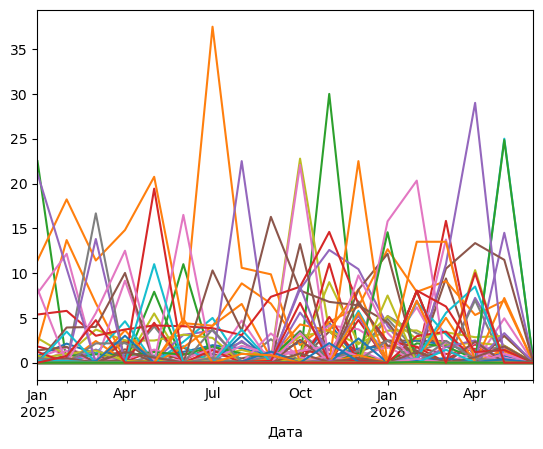

In [ ]:
# динамика цен всех поставщиков
time_s.plot(legend=False)

In [ ]:
# Переводим данные в матрицу для tslearn (транспонируем)
X_raw = time_s.T.values

# Нормируем данные по форме (Z-масштабирование)
scaler = TimeSeriesScalerMeanVariance(mu=0.0, std=1.0)
X_scaled = scaler.fit_transform(X_raw)

Запуск расчета инерции для поиска 'локтя'...
Оцениваем разбиение на 2 кластеров...
Оцениваем разбиение на 3 кластеров...
Оцениваем разбиение на 4 кластеров...
Оцениваем разбиение на 5 кластеров...
Оцениваем разбиение на 6 кластеров...


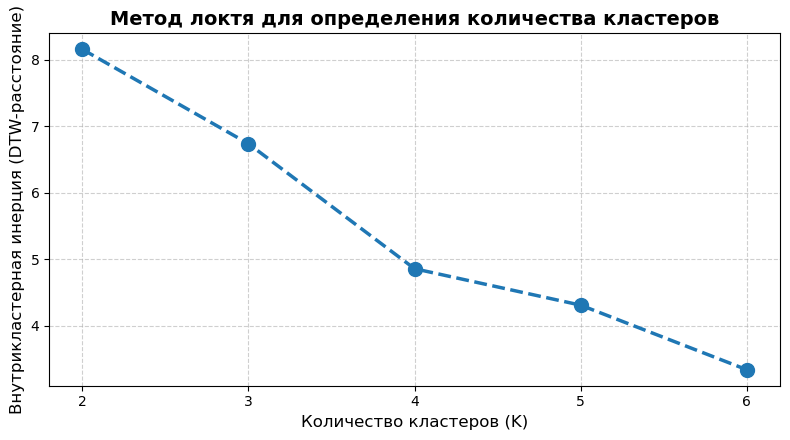

In [ ]:
# сколько кластеров возьмем для разделения поставщиков по динамике цен?
# Диапазон количества кластеров для проверки (например, от 2 до 6)
cluster_range = range(2, 7)
inertias = []

print("Запуск расчета инерции для поиска 'локтя'...")

for k in cluster_range:
    print(f"Оцениваем разбиение на {k} кластеров...")
    model_eval = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        metric_params={"global_constraint": "sakoe_chiba", "sakoe_chiba_radius": 2},
        max_iter=30,  # Ограничим итерации для ускорения теста
        random_state=42,
        n_jobs=-1
    )
    model_eval.fit(X_scaled)
    inertias.append(model_eval.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(8, 4.5))
plt.plot(cluster_range, inertias, marker='o', markersize=10, color='#1f77b4', linewidth=2.5, linestyle='--')
plt.title("Метод локтя для определения количества кластеров", fontsize=14, fontweight='bold')
plt.xlabel("Количество кластеров (K)", fontsize=12)
plt.ylabel("Внутрикластерная инерция (DTW-расстояние)", fontsize=12)
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Найдено 66 уникальных наименований. Начинаем цикл обработки...
Пропуск 'ИВЛИЗИ': слишком мало поставщиков (1).


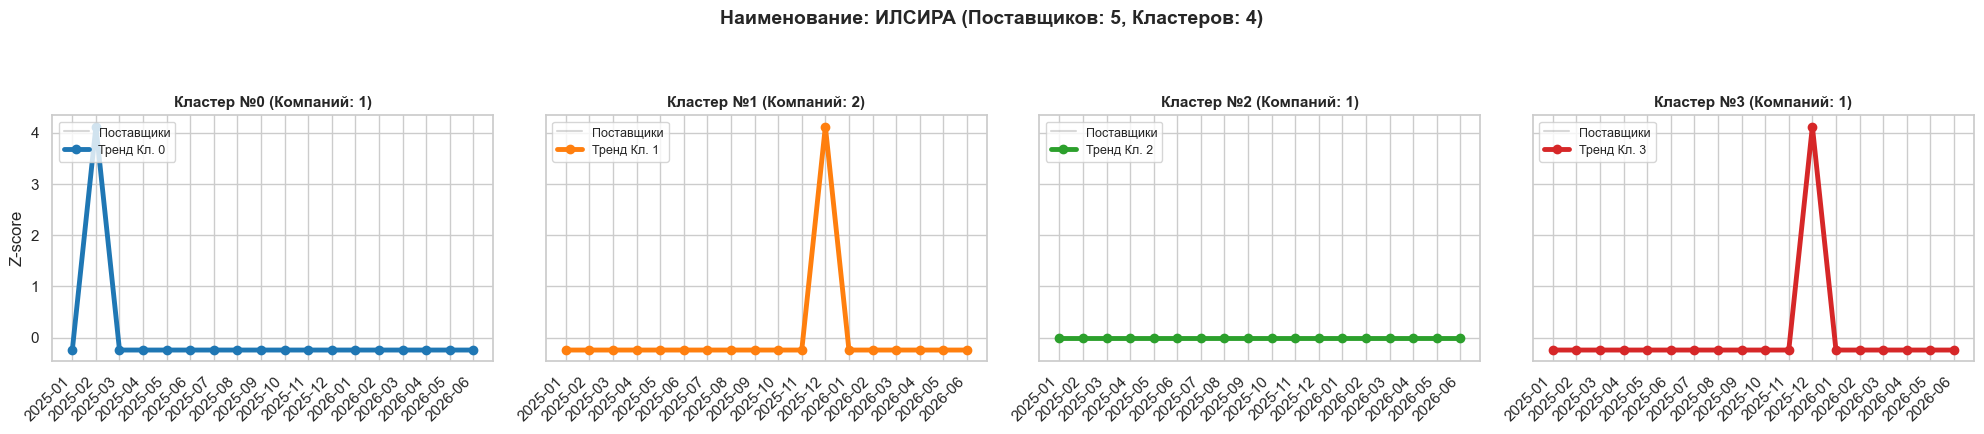

Пропуск 'НУРДАТИ': слишком мало поставщиков (1).


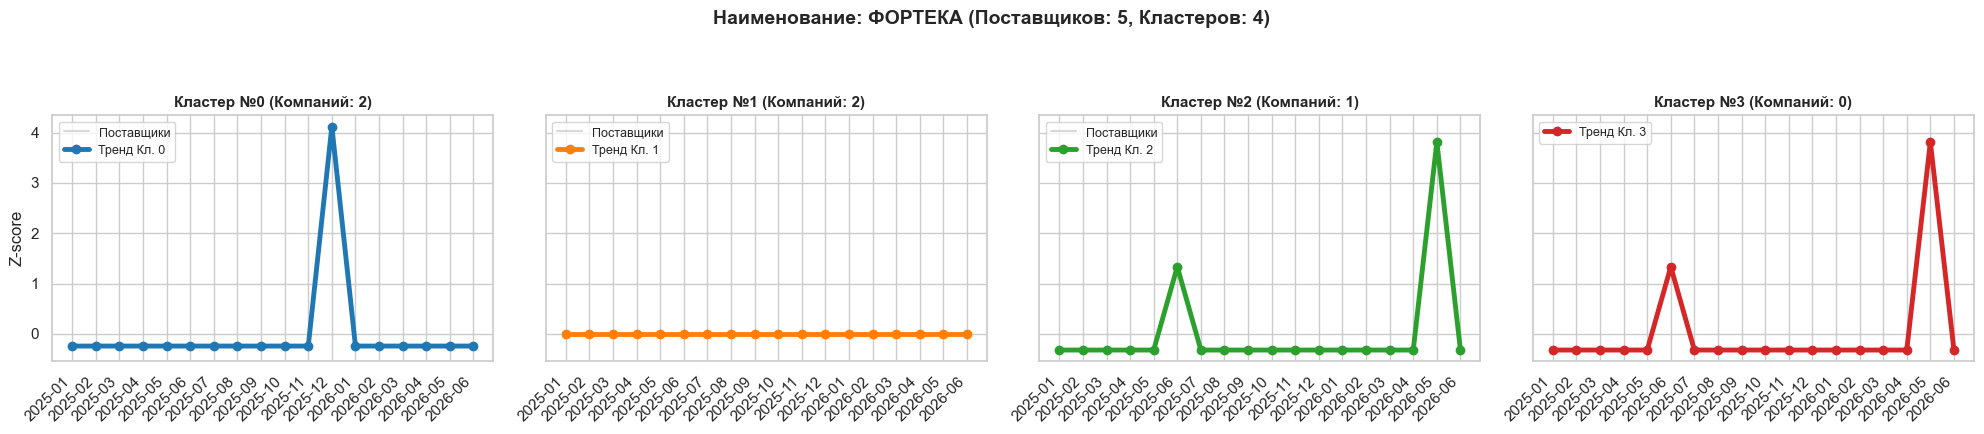

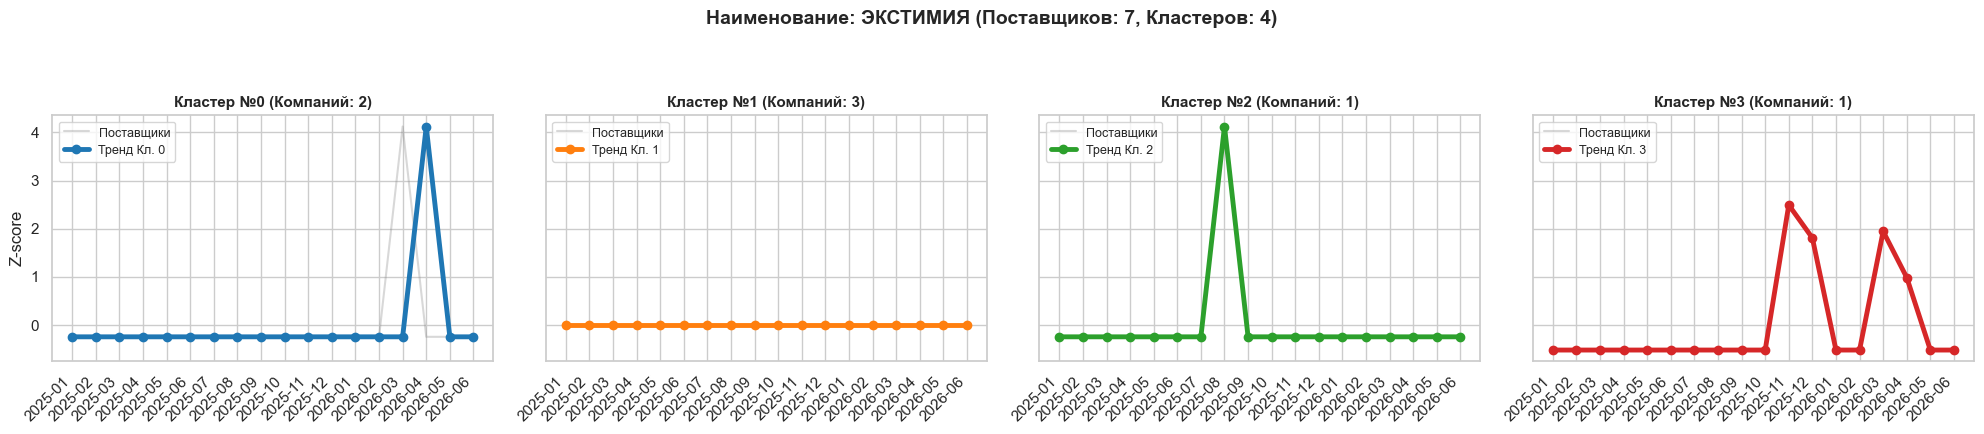

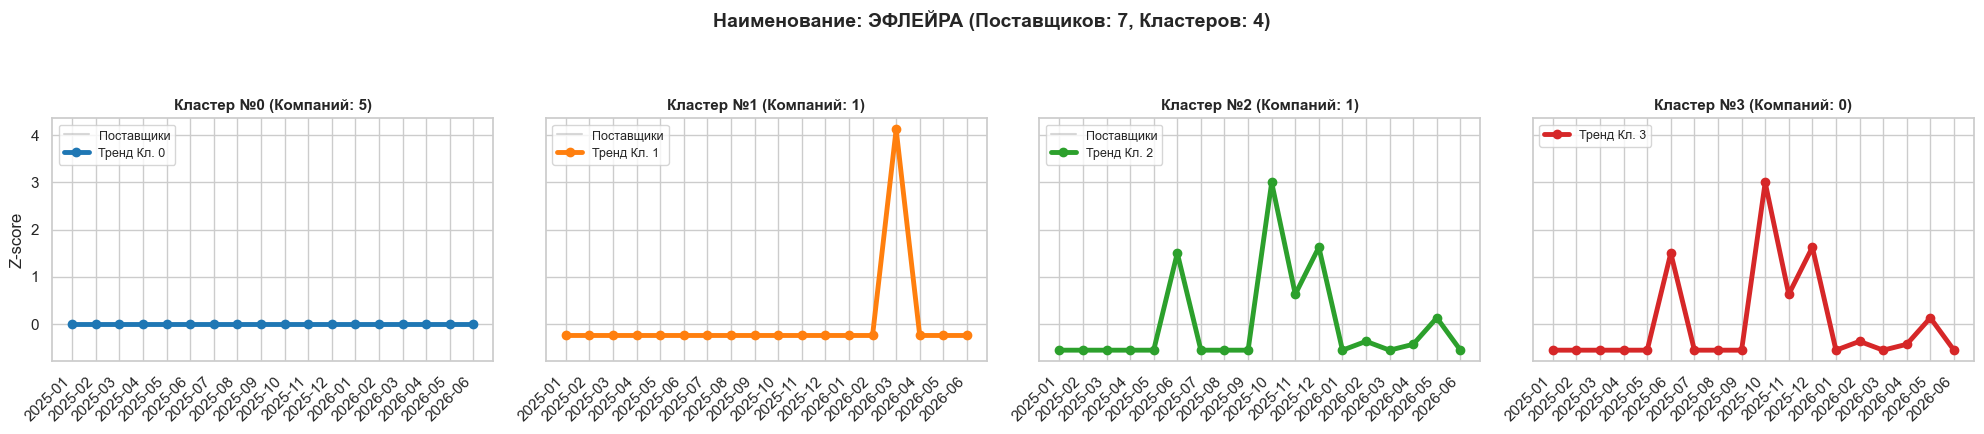

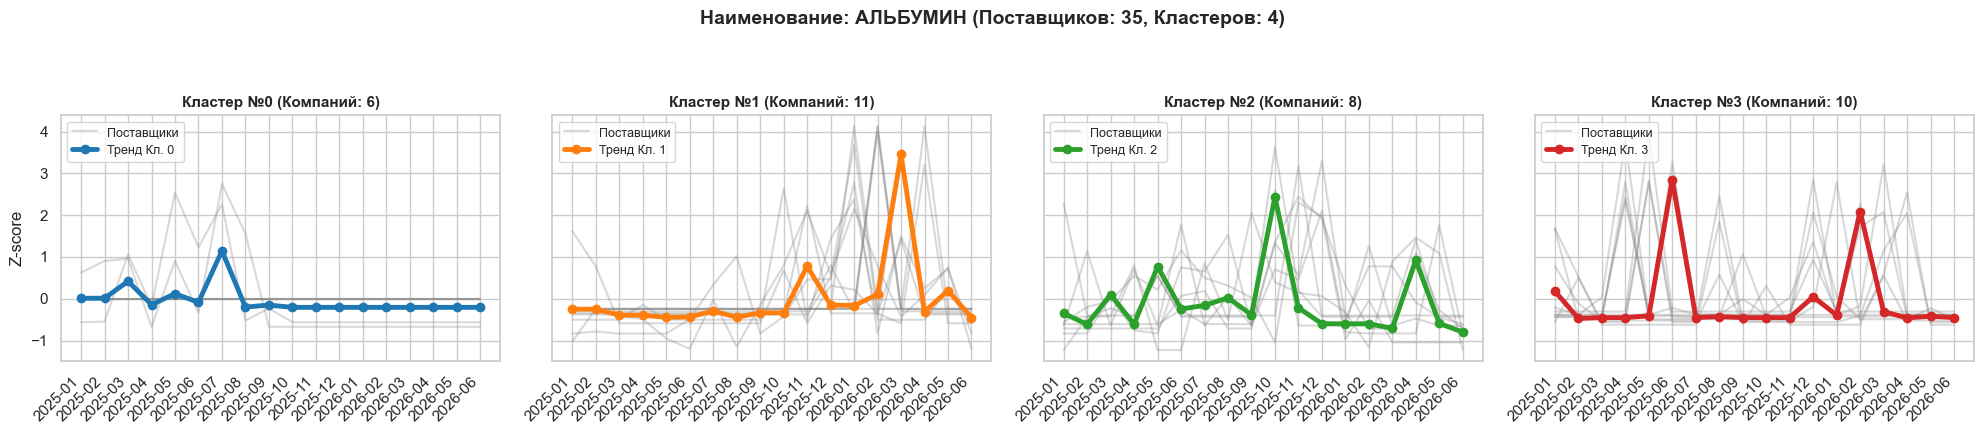

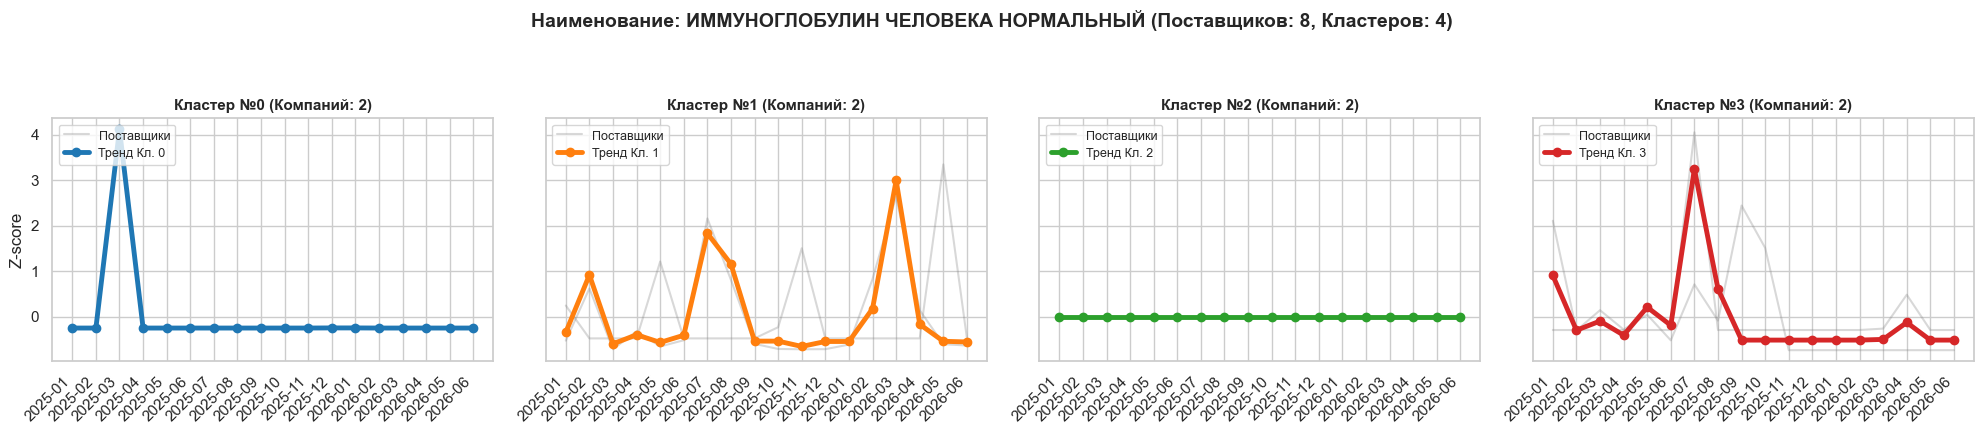

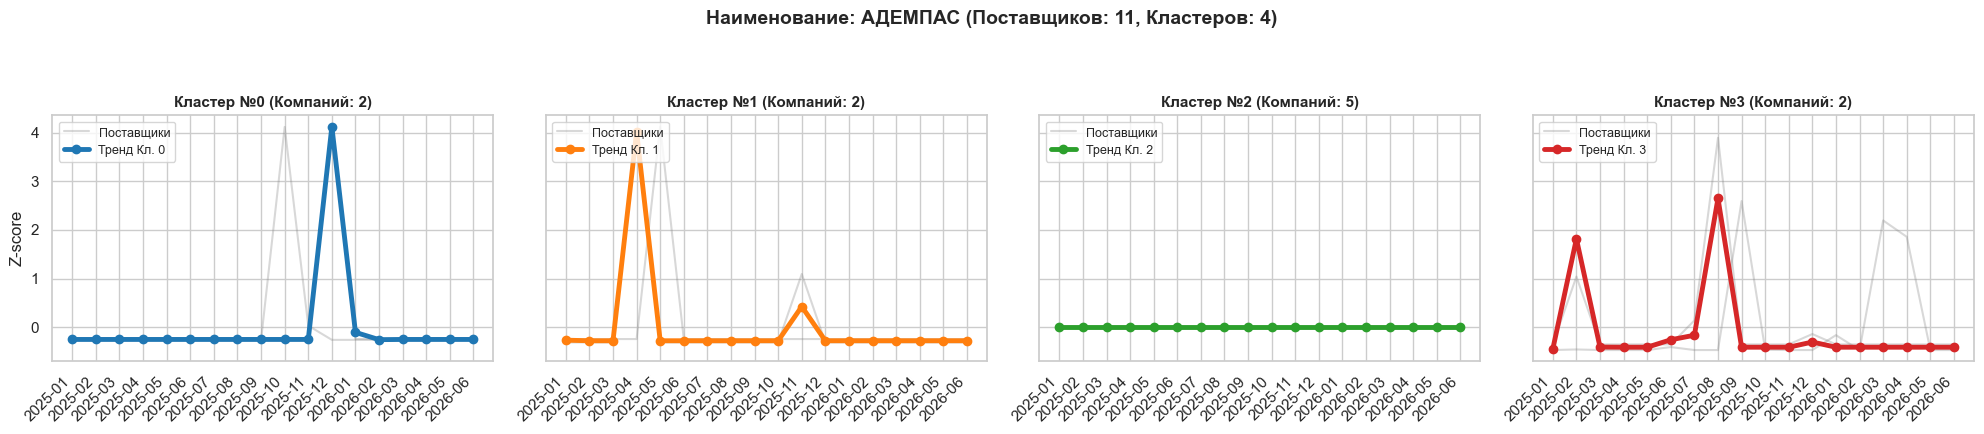

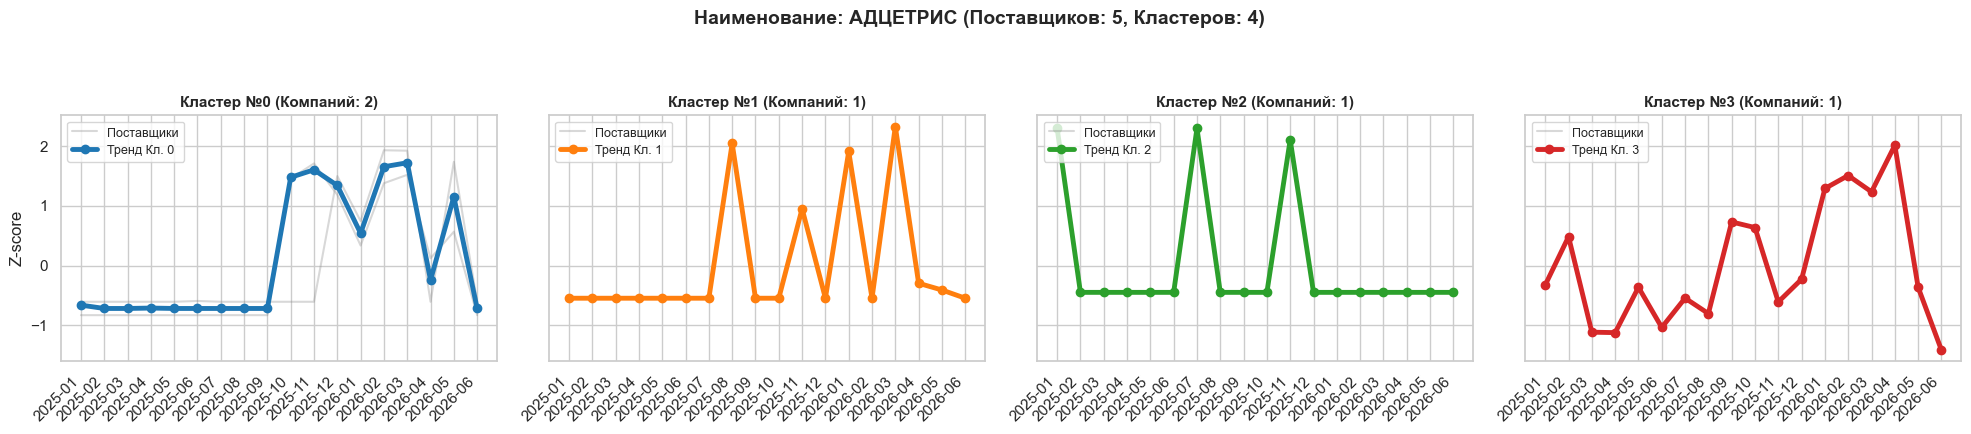

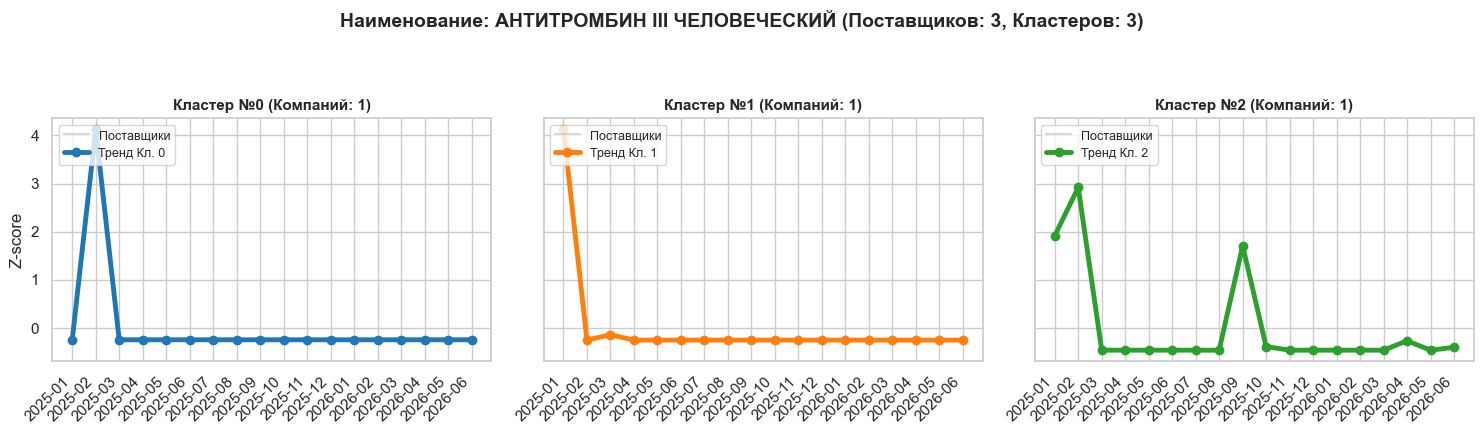

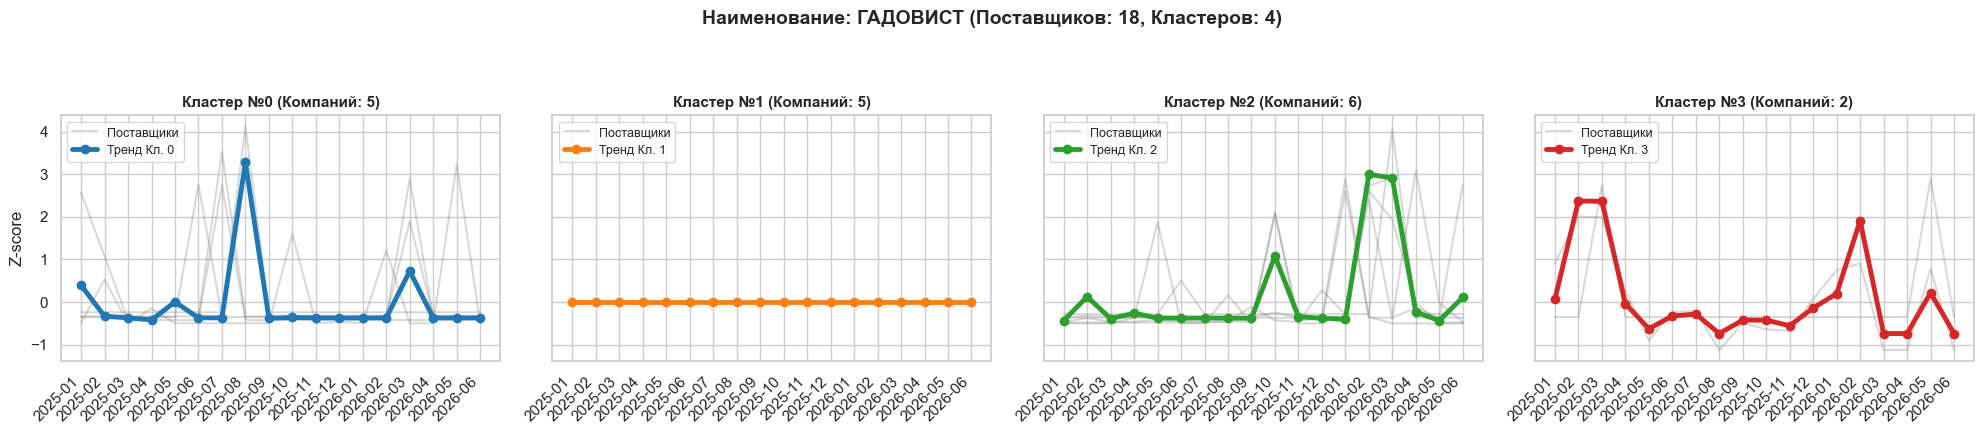

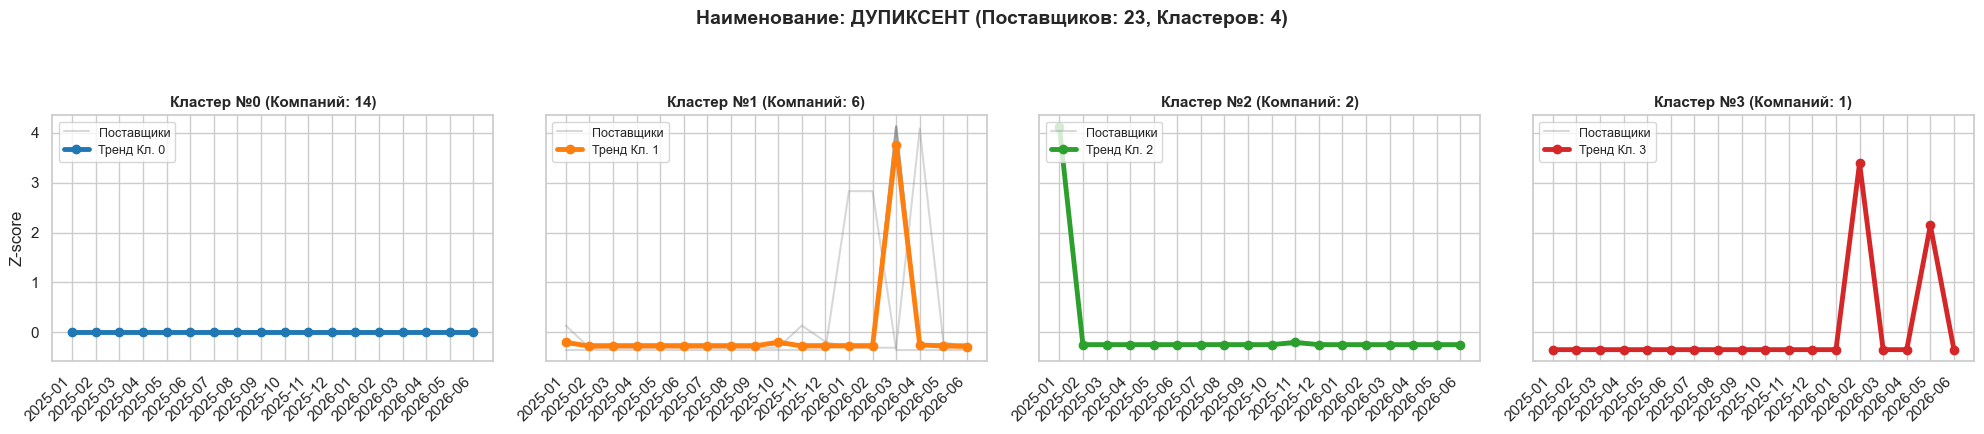

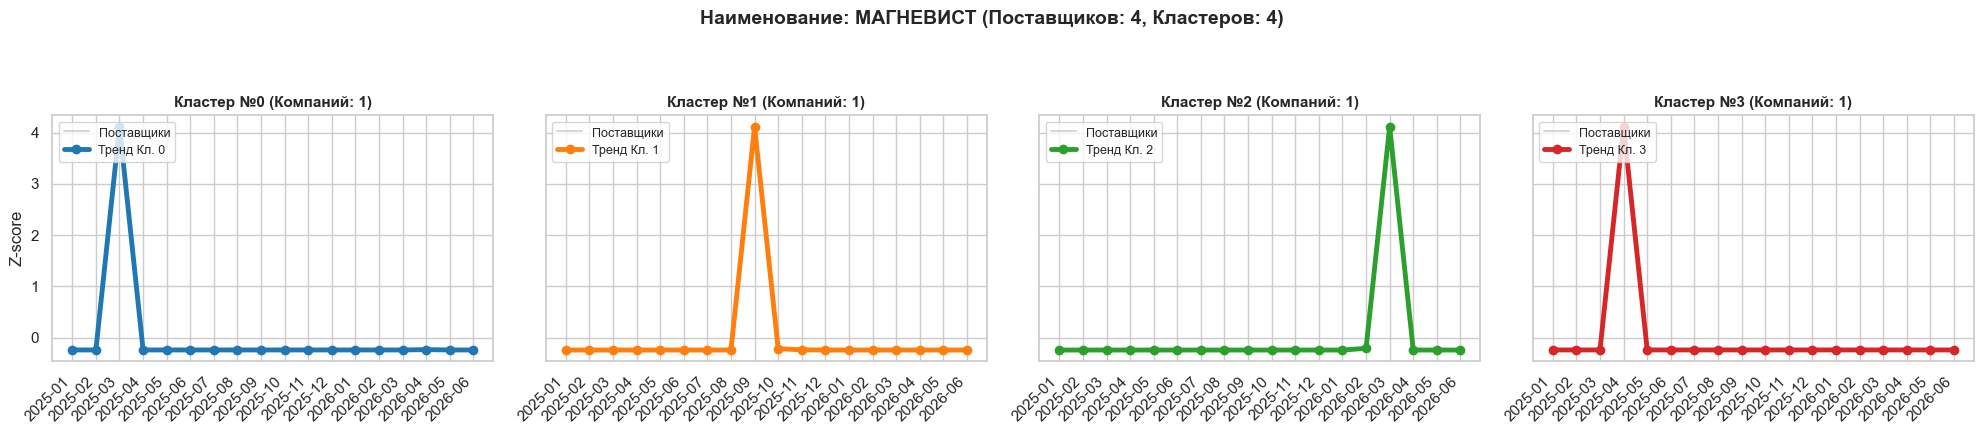

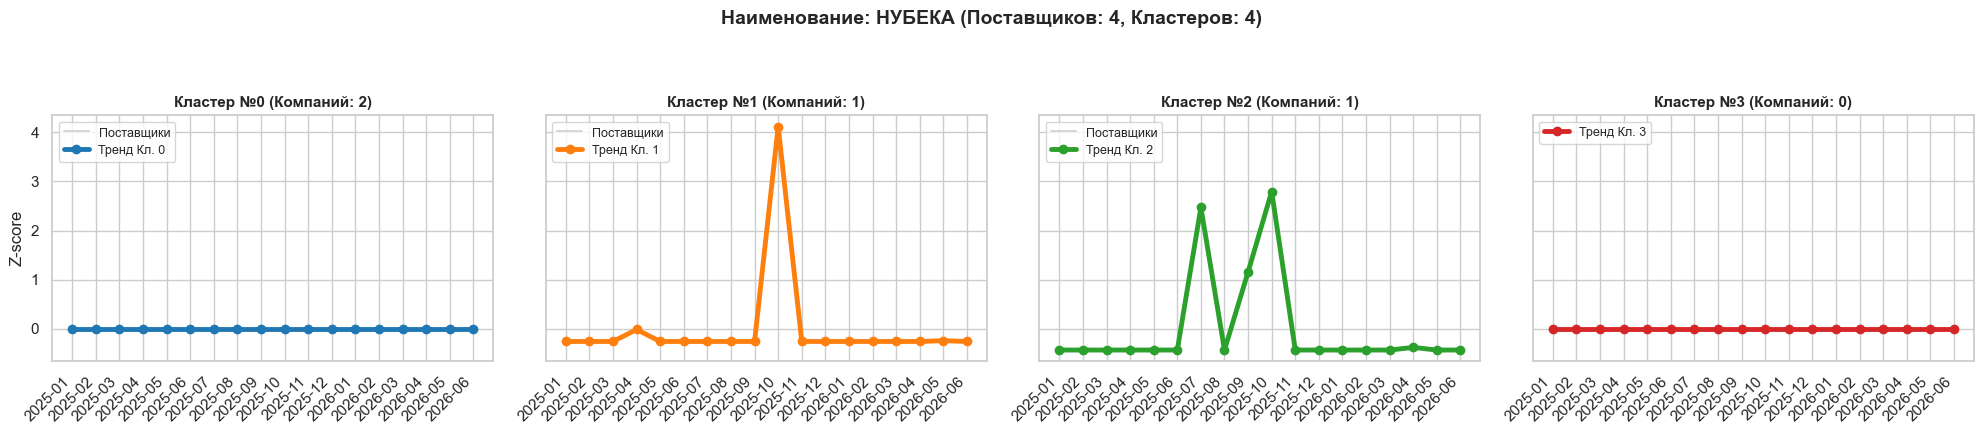

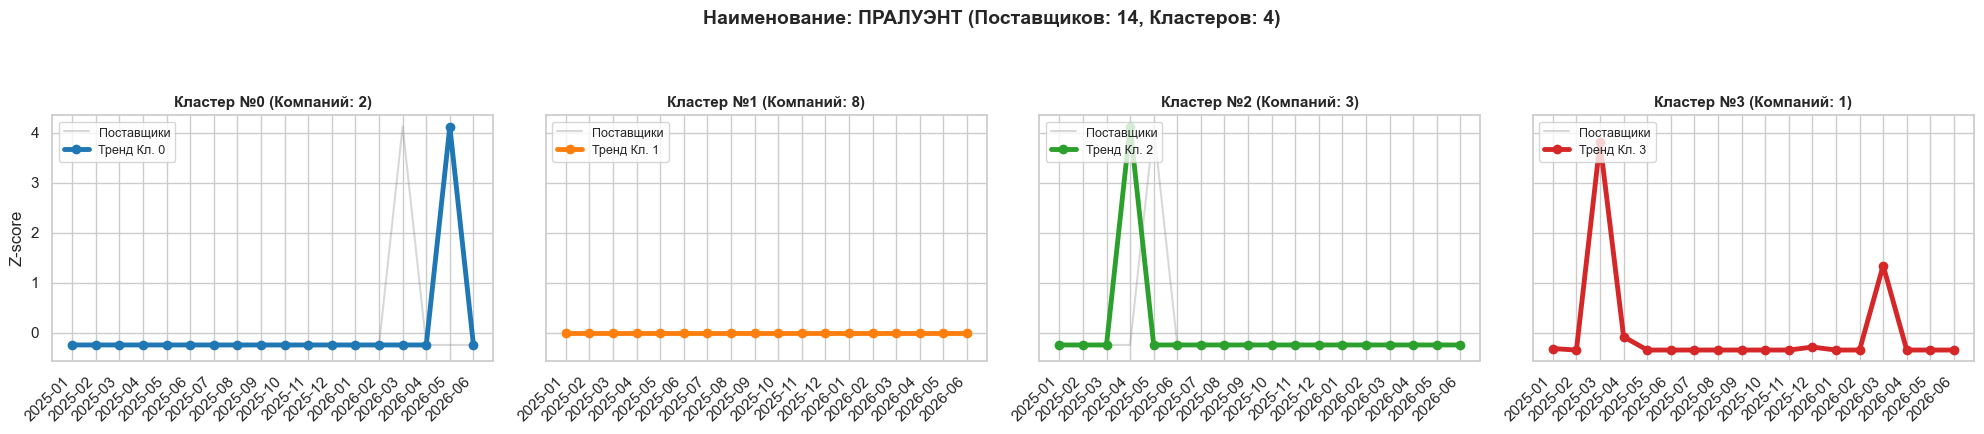

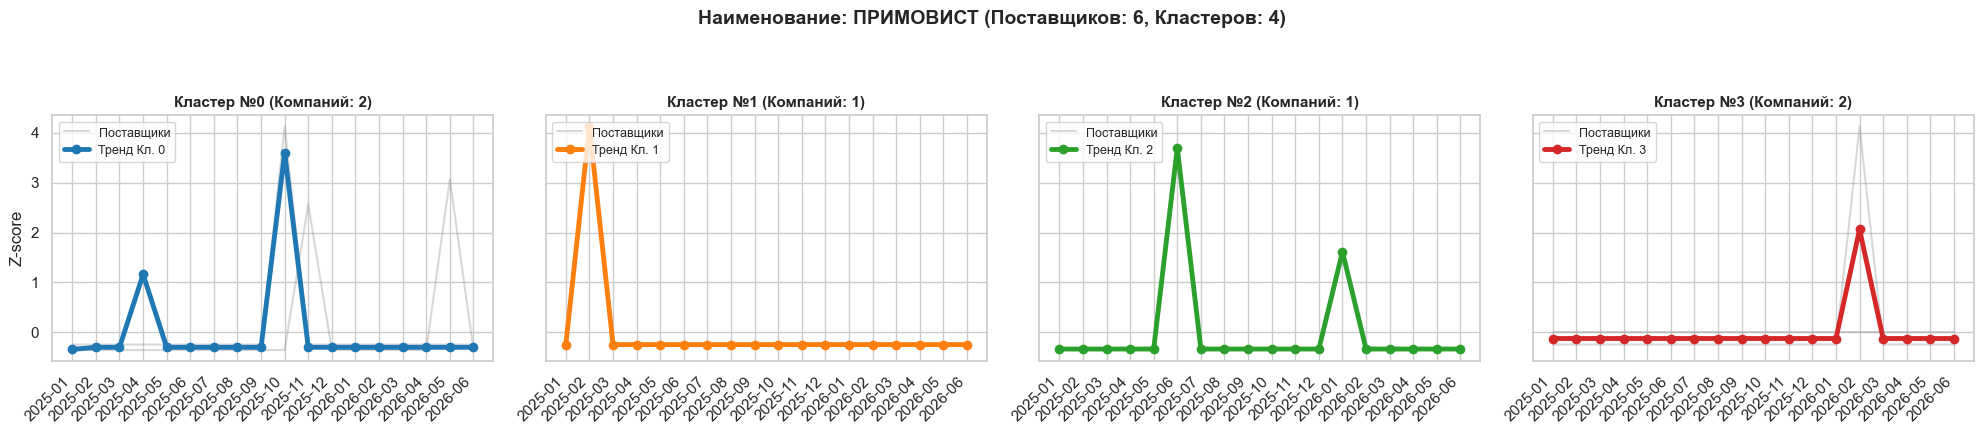

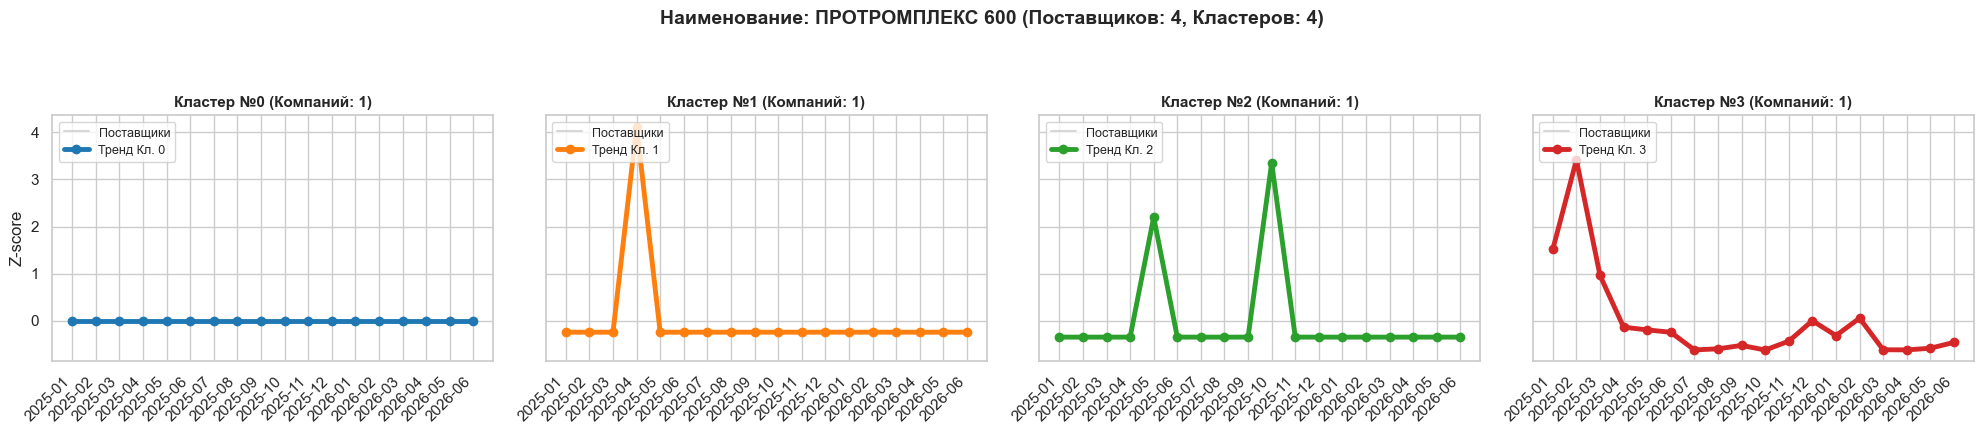

Пропуск 'РЕСПИКАМ': слишком мало поставщиков (1).


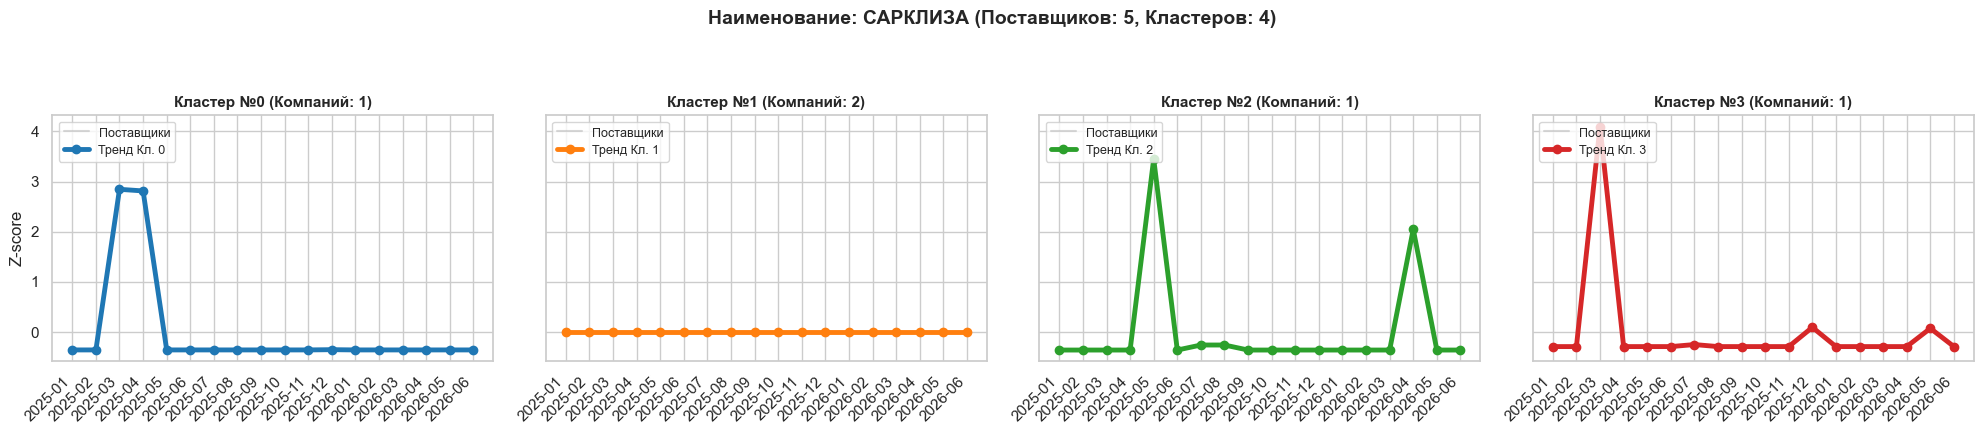

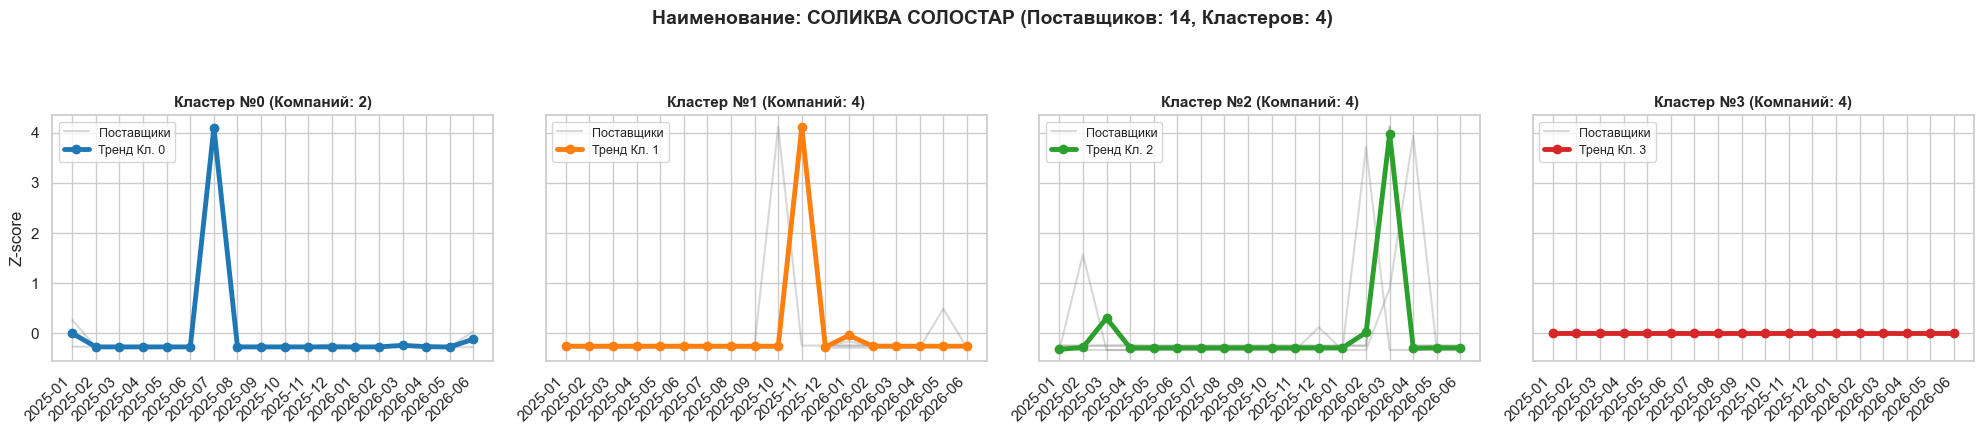

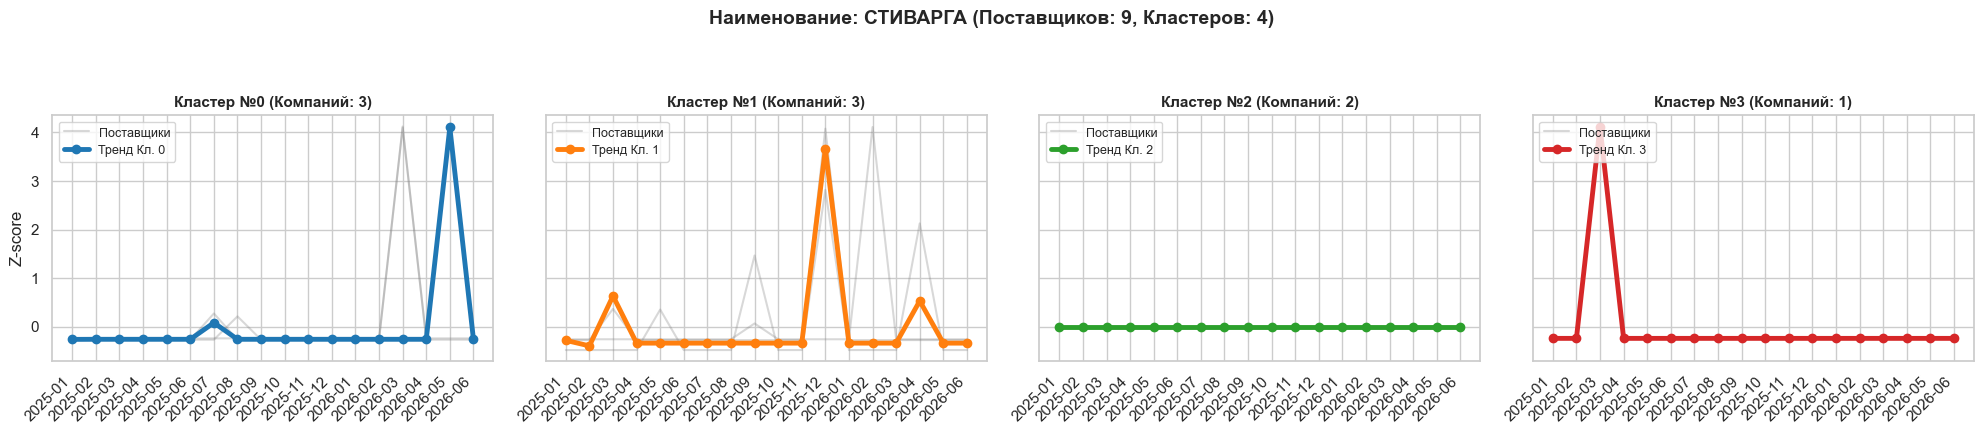

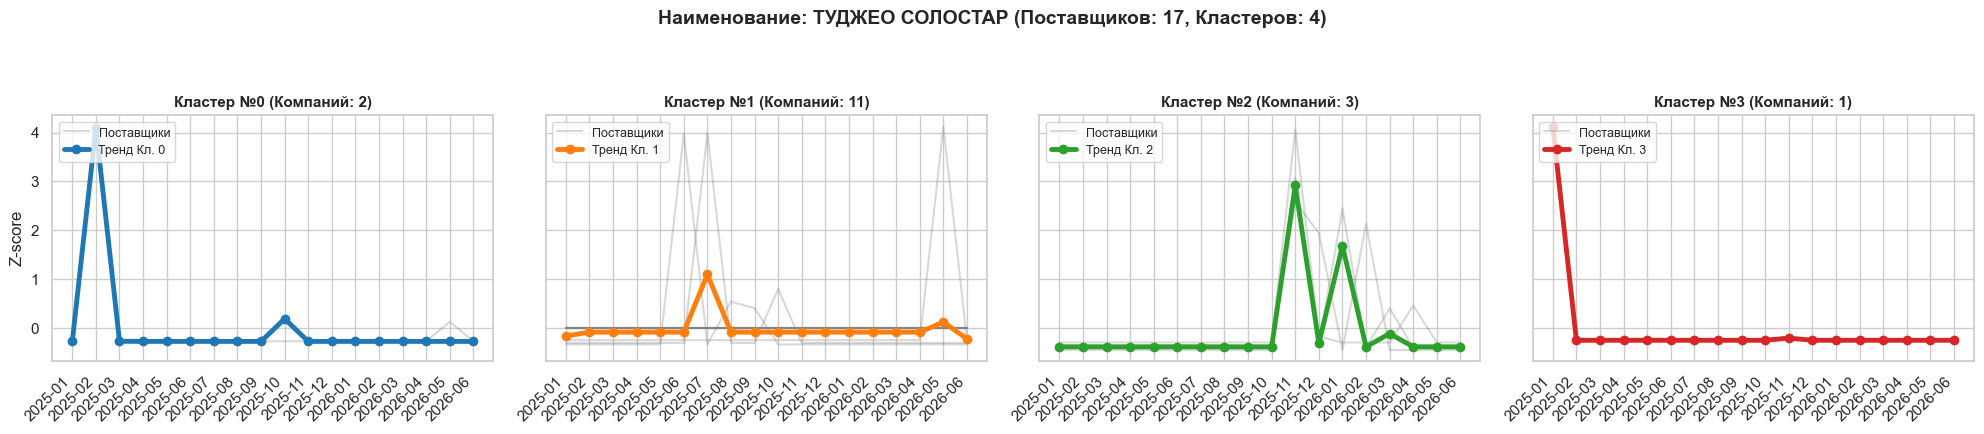

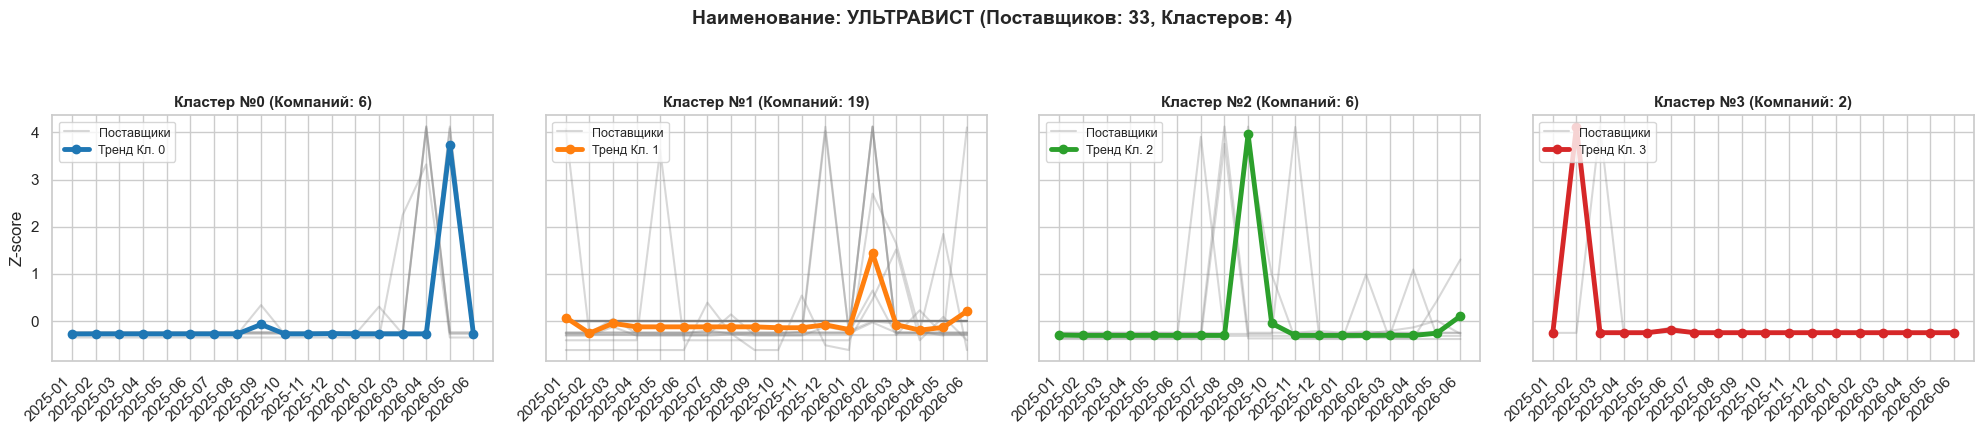

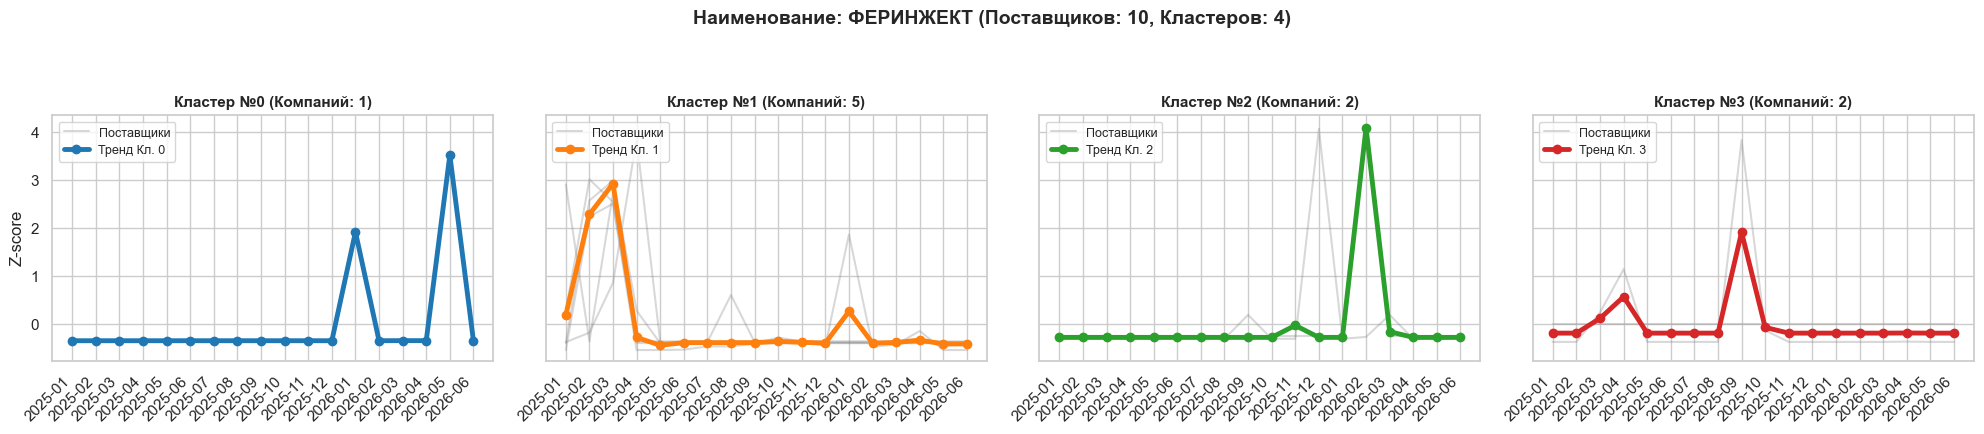

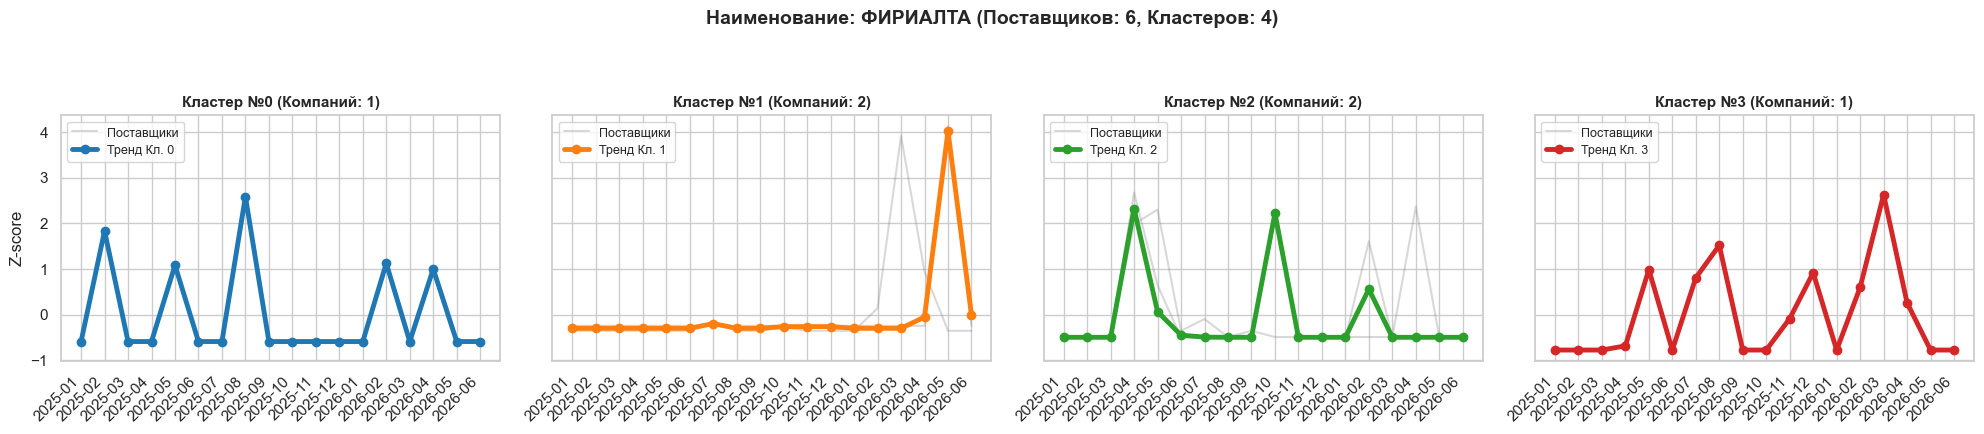

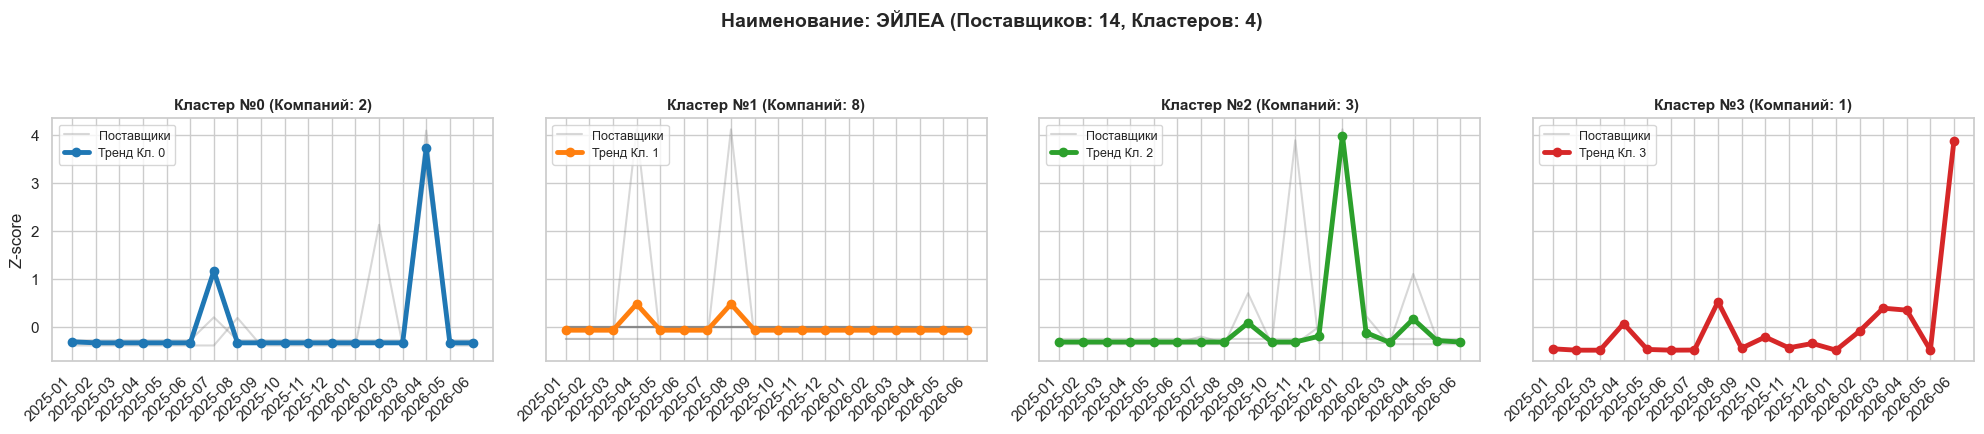

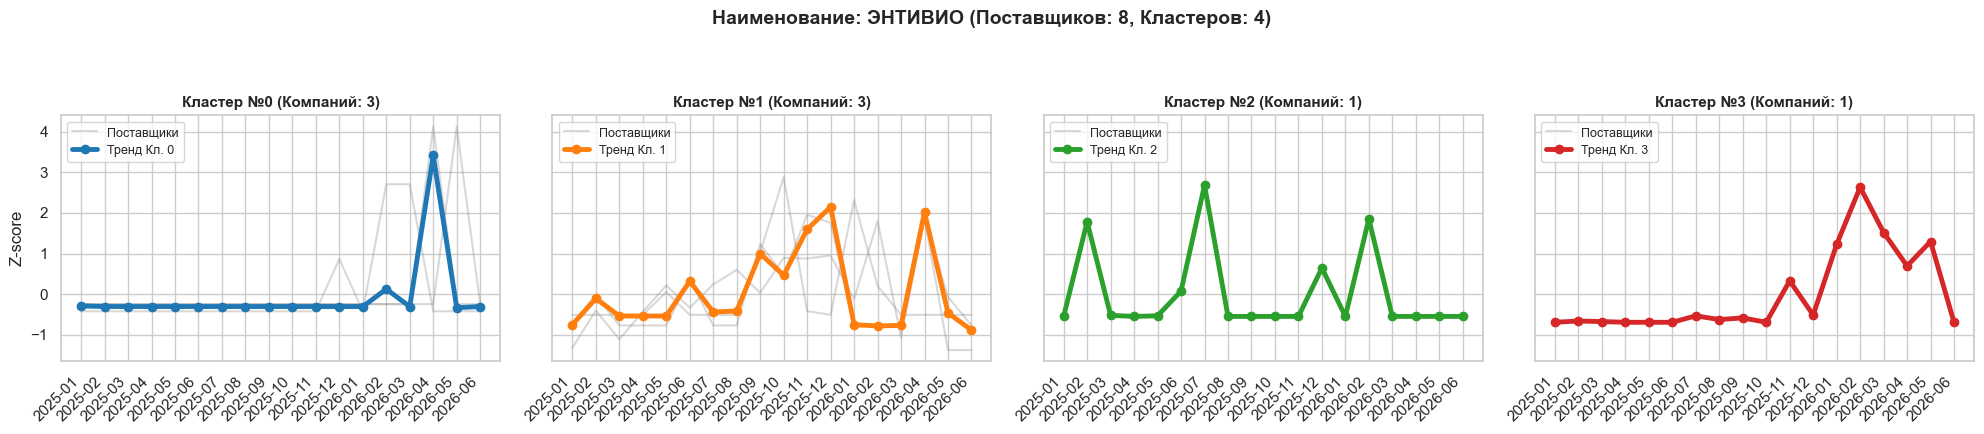

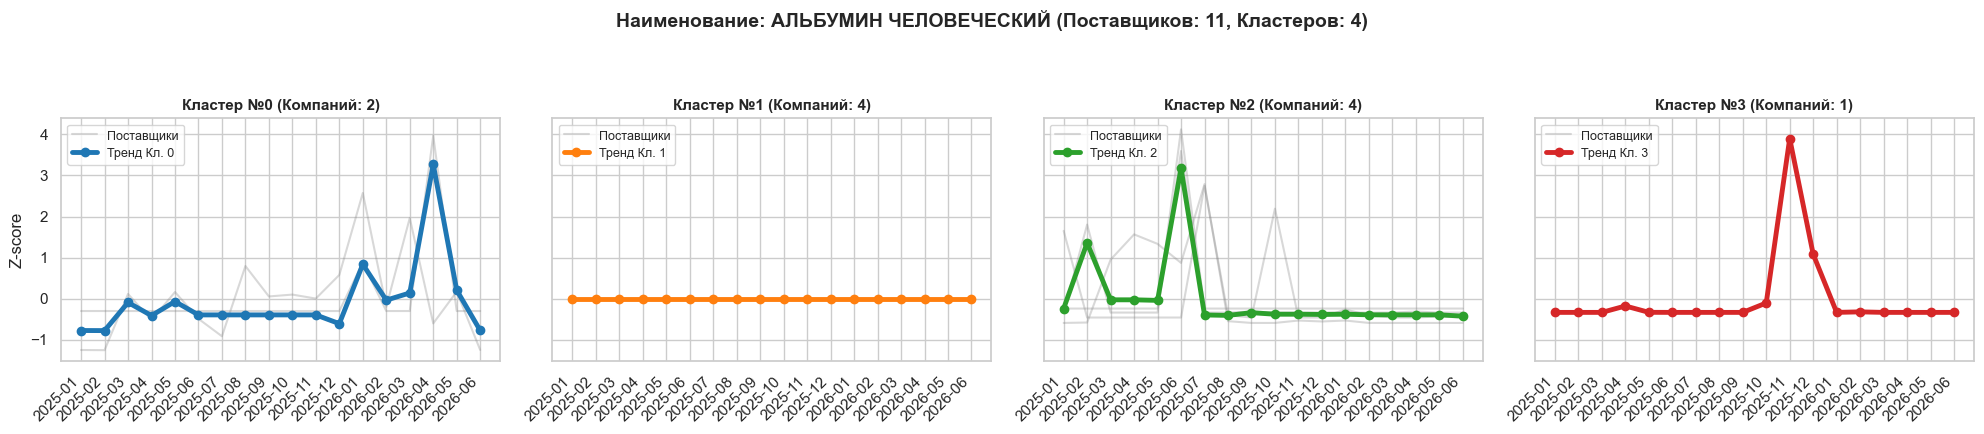

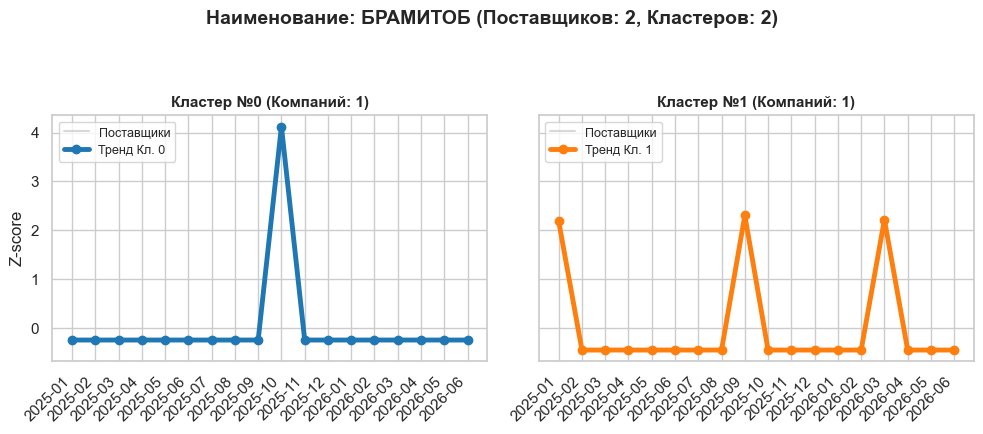

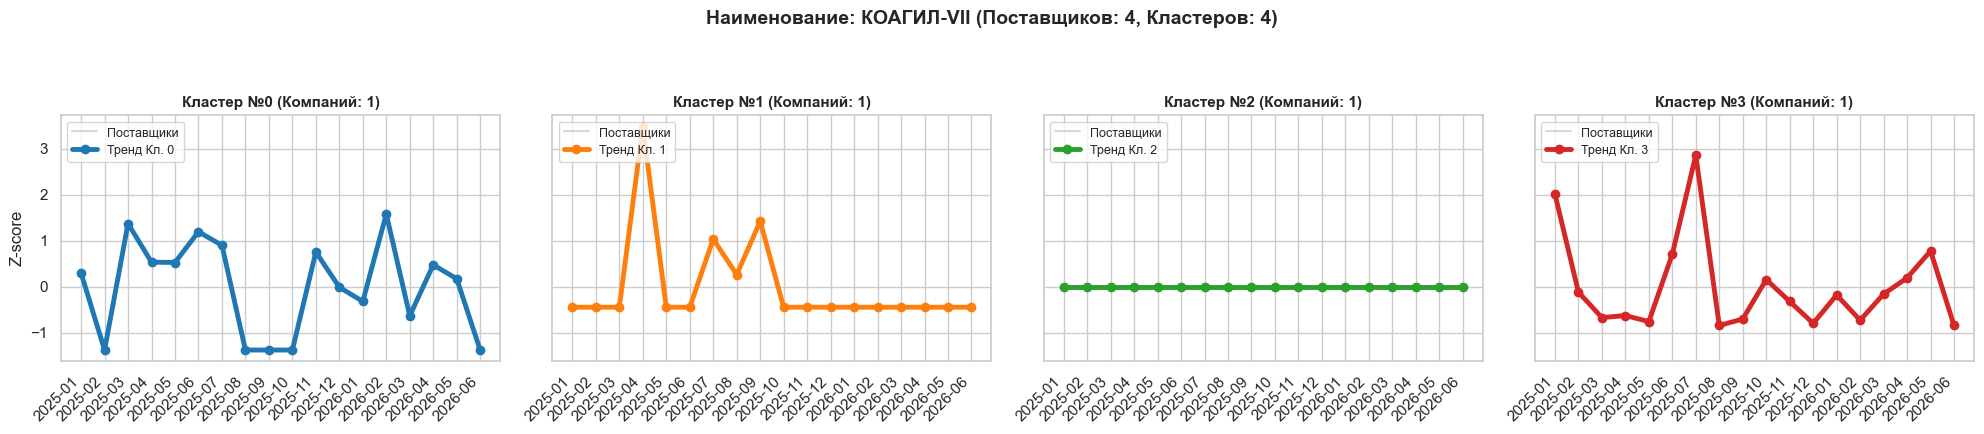

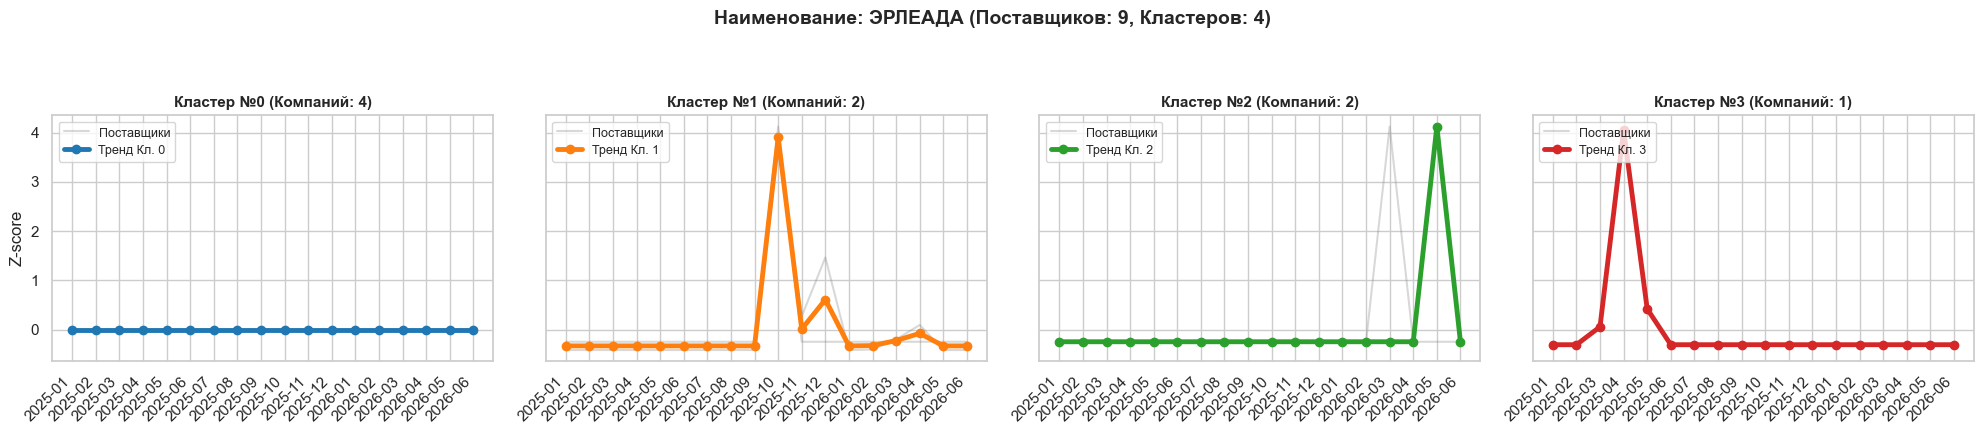

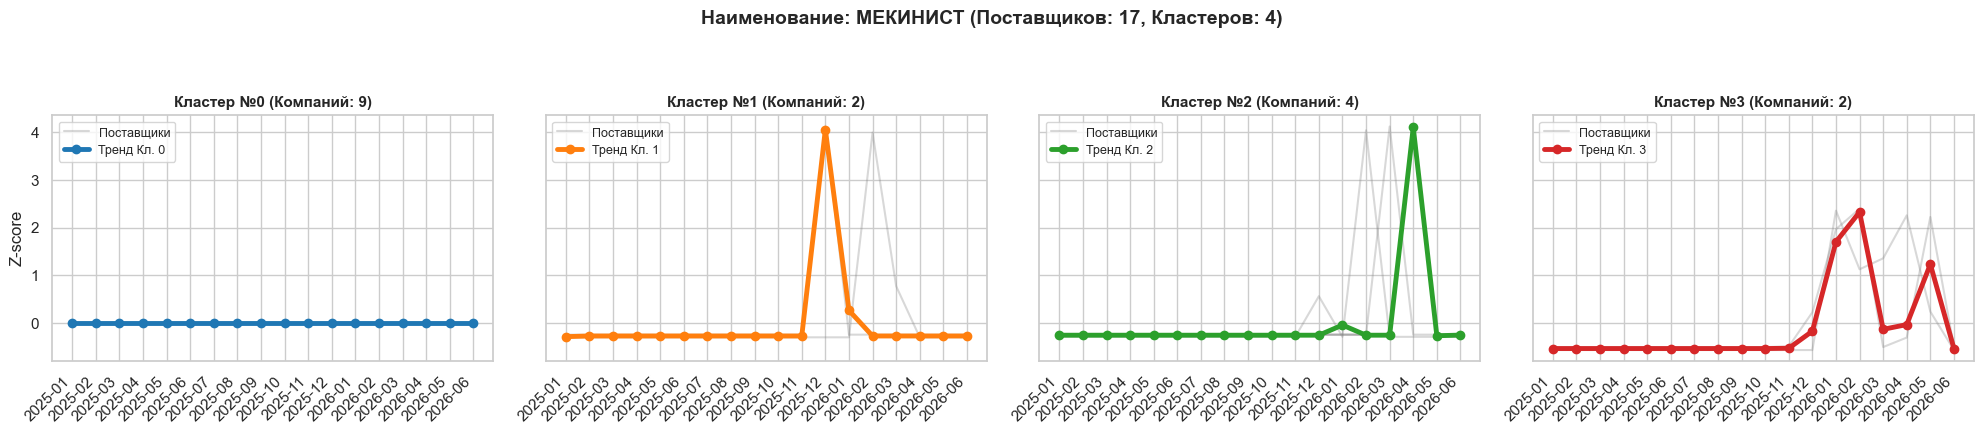

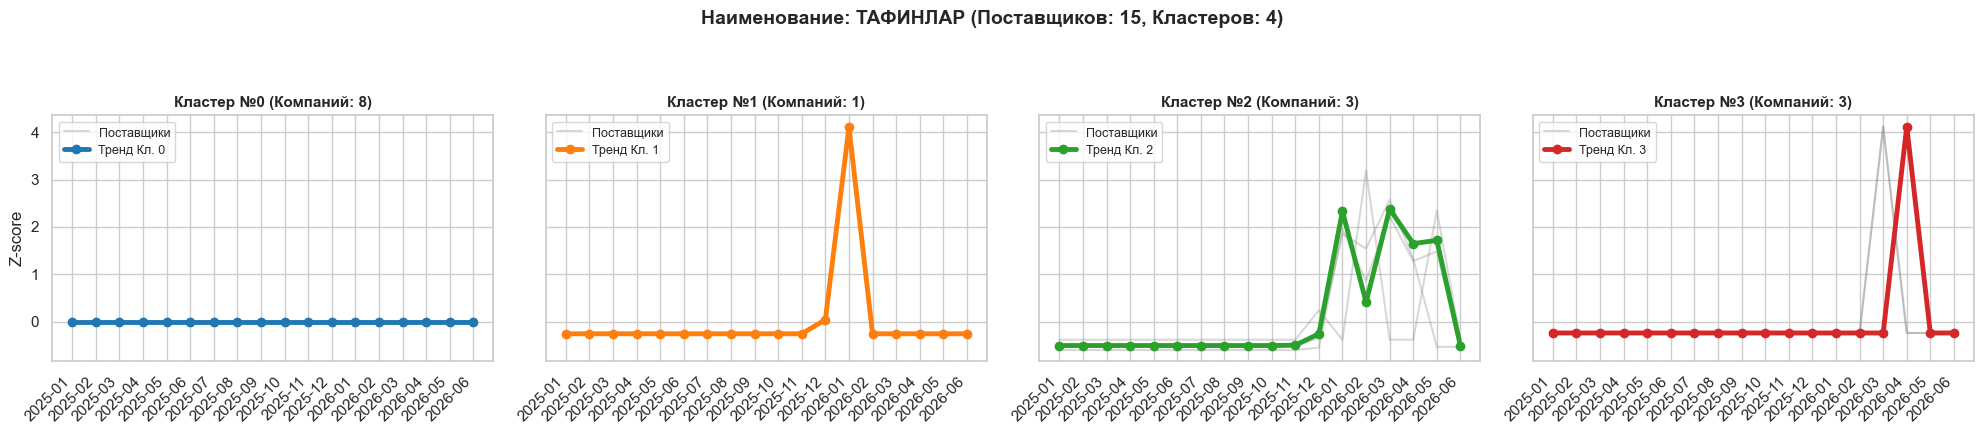

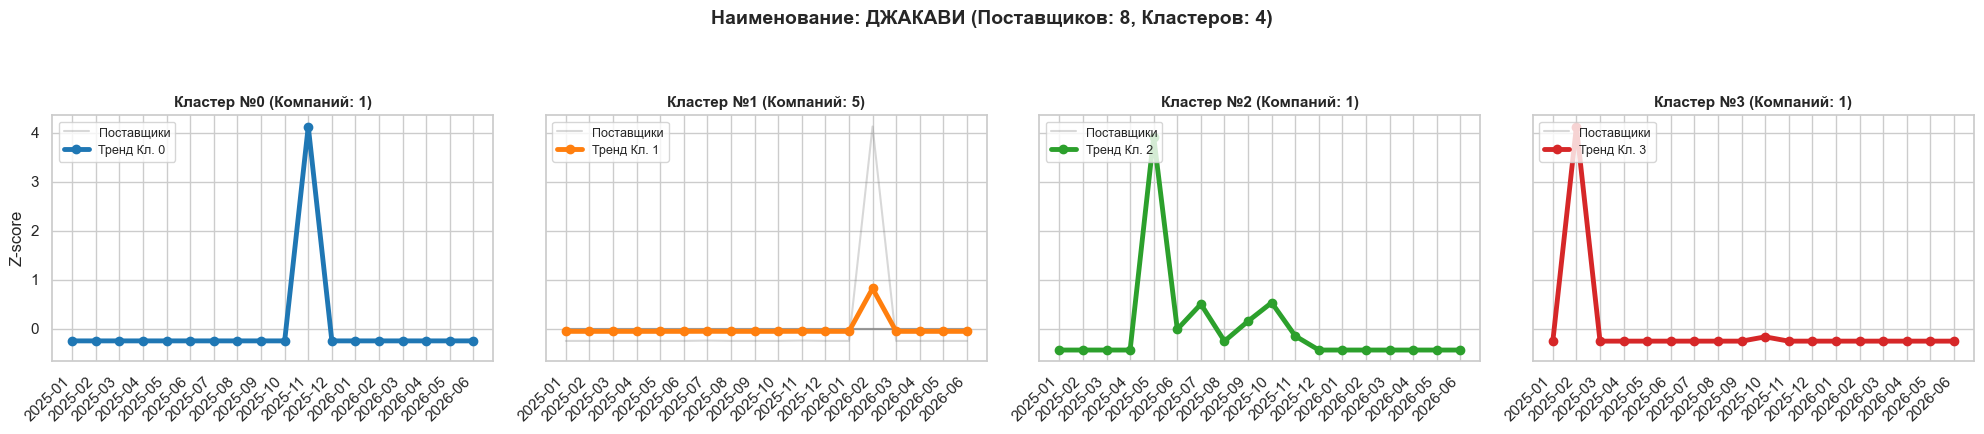

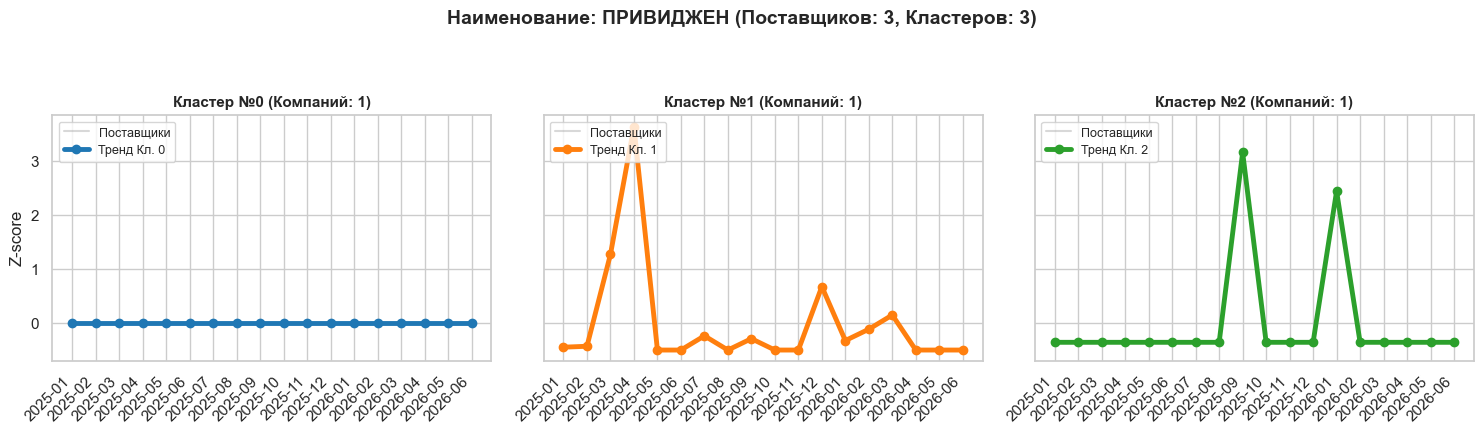

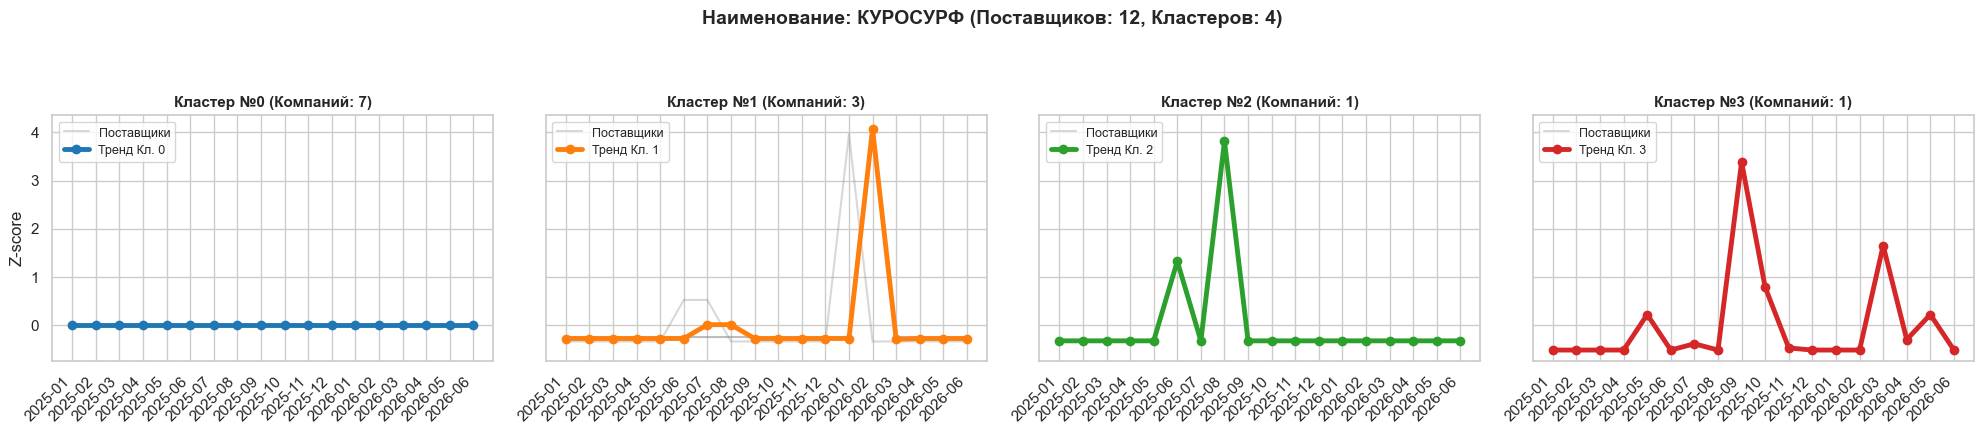

Пропуск 'АЛЬБУРЕКС': слишком мало поставщиков (1).
Пропуск 'АЛЬБУФАРМ': слишком мало поставщиков (1).
Пропуск 'АПАЛУТАМИД-АМЕДАРТ': слишком мало поставщиков (1).


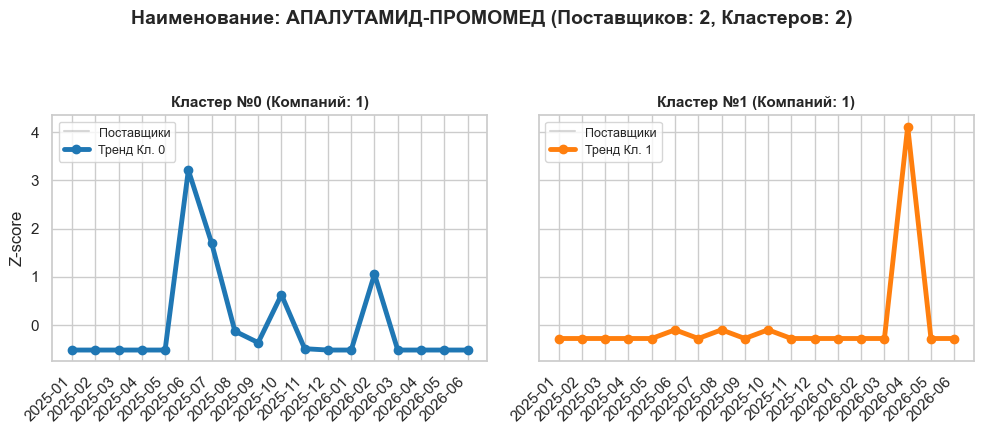

Пропуск 'БЕРИНЕРТ': слишком мало поставщиков (1).


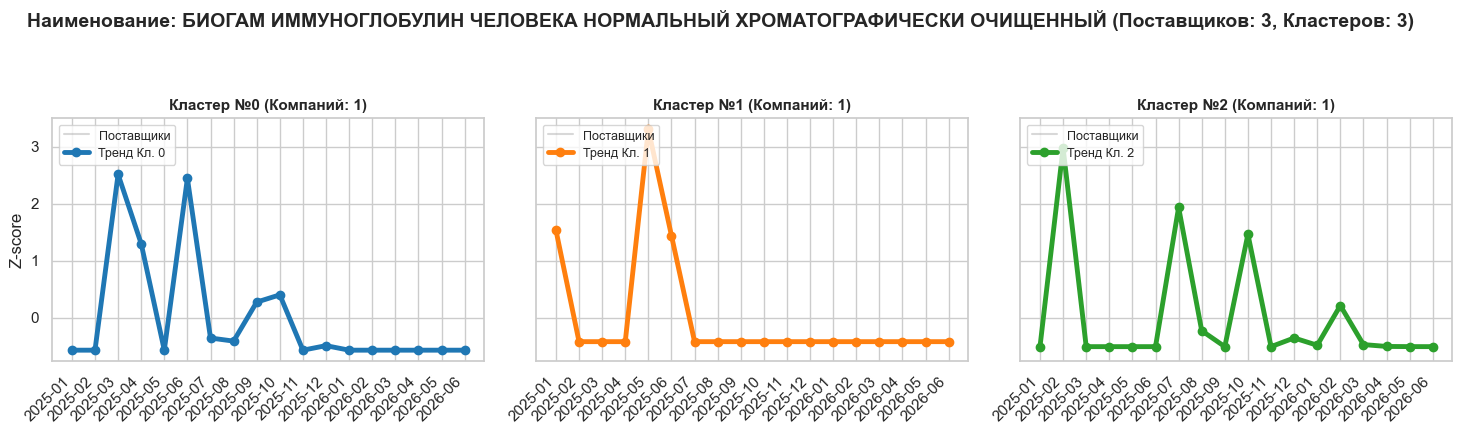

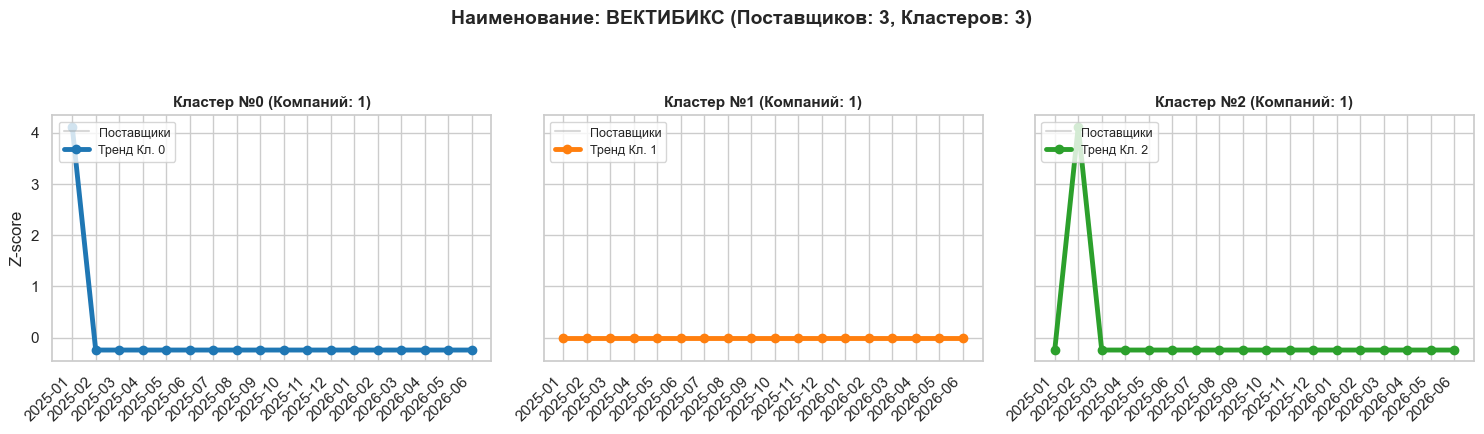

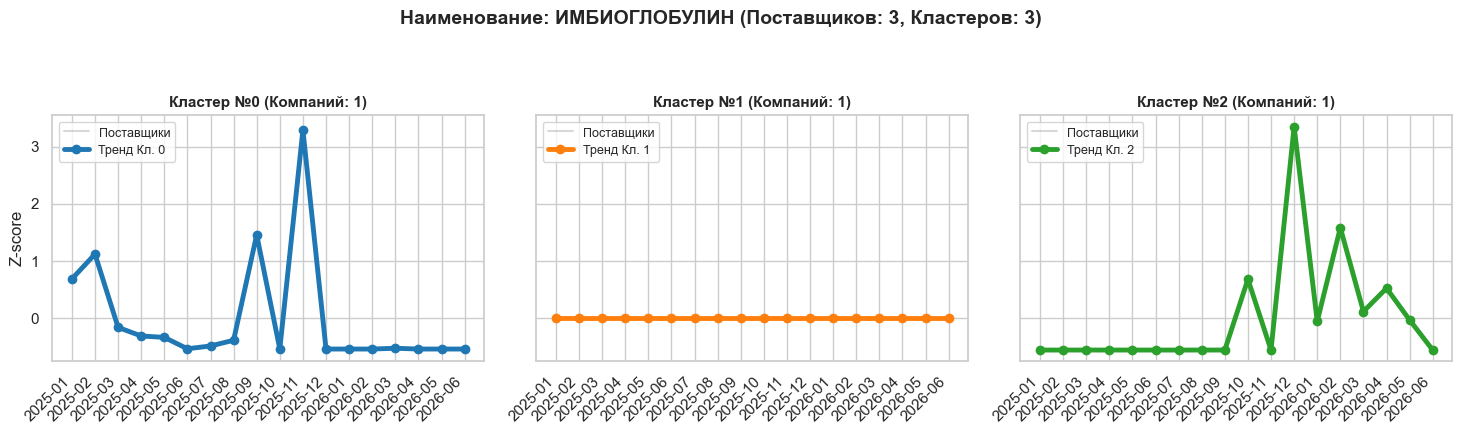

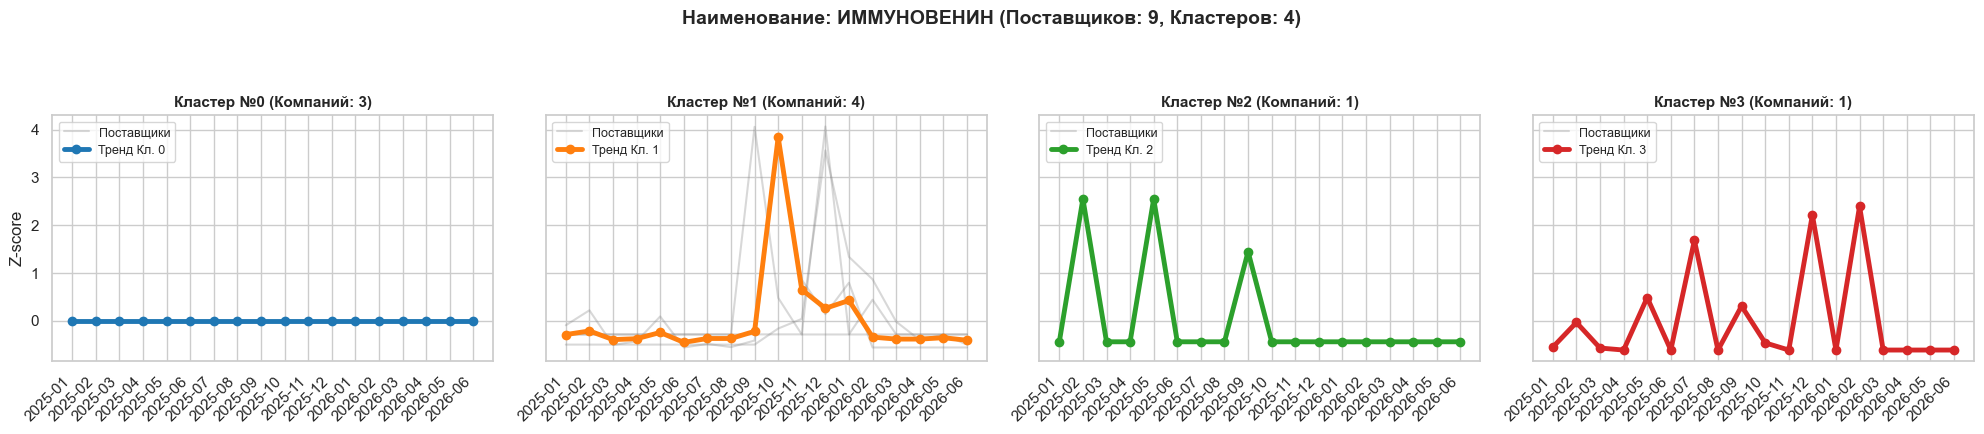

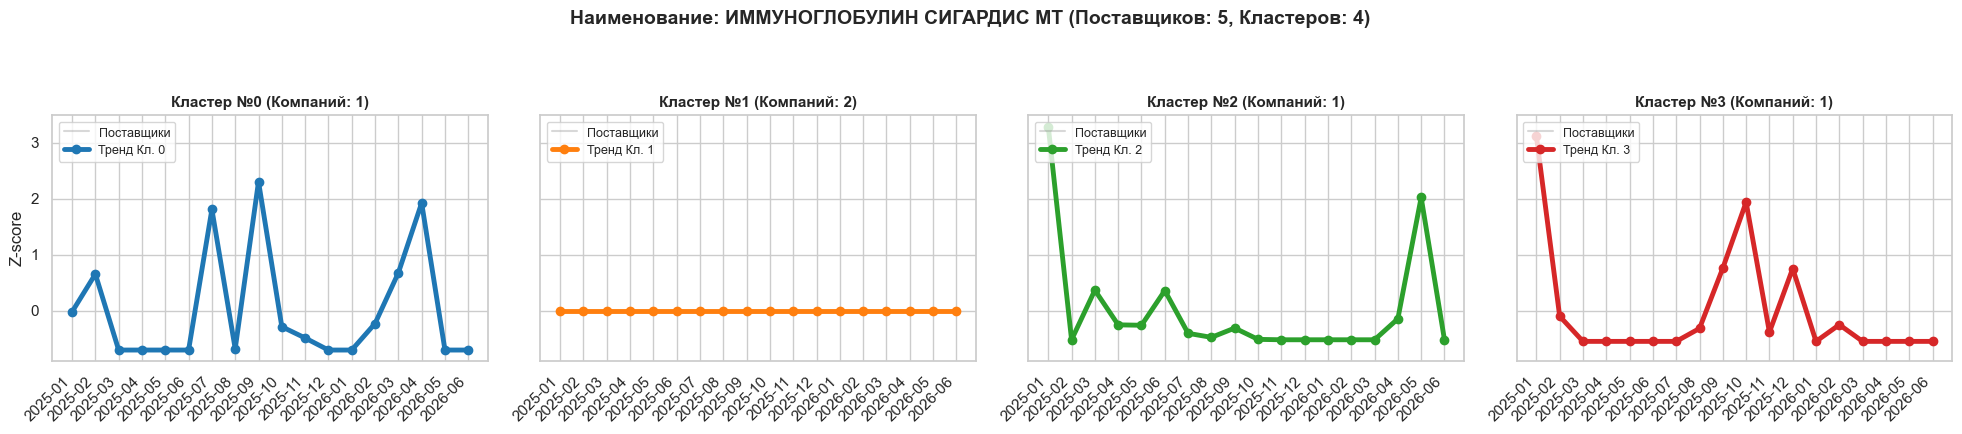

Пропуск 'ИММУНОРО КЕДРИОН': слишком мало поставщиков (1).
Пропуск 'КАРФИЛЗОМИБ-ПРОМОМЕД': слишком мало поставщиков (1).
Пропуск 'КИПРОЛИС': слишком мало поставщиков (1).


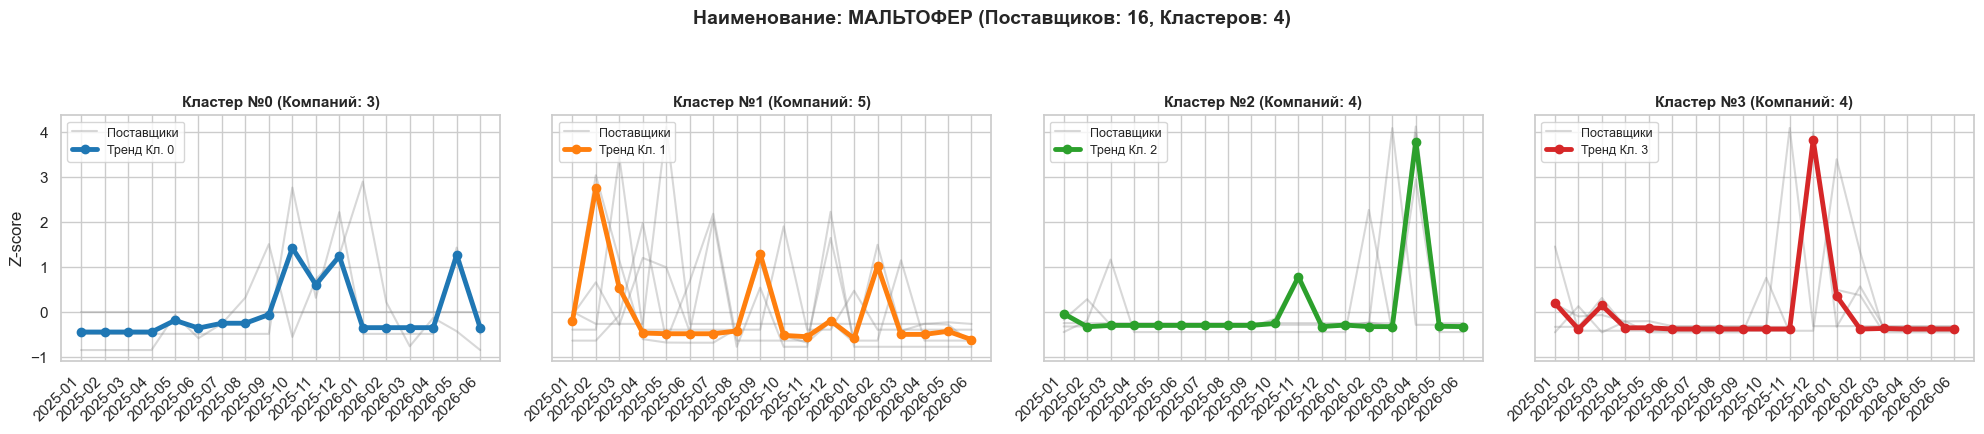

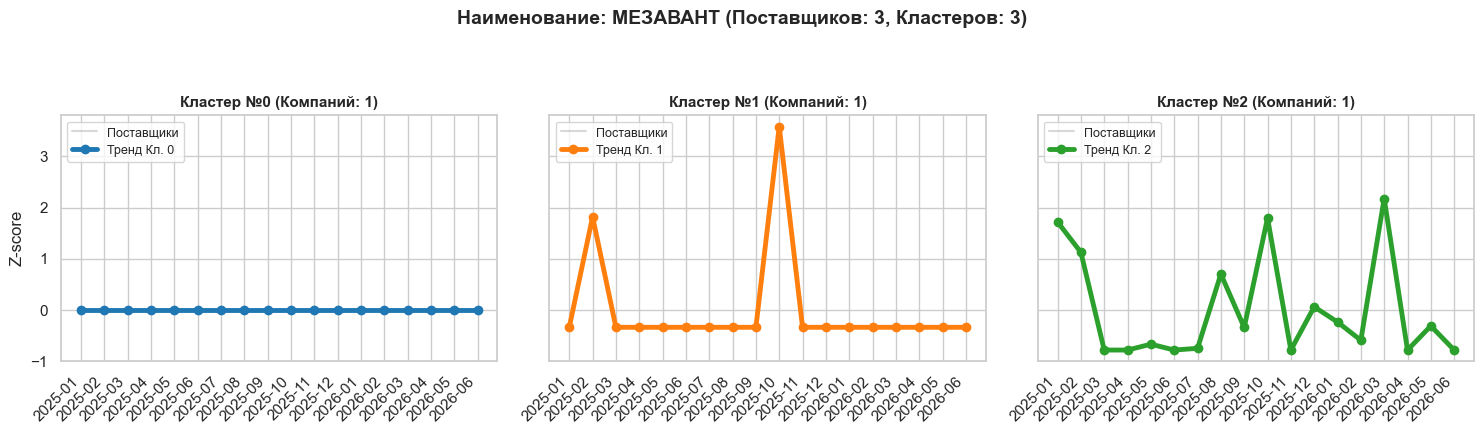

Пропуск 'НЕОЦИТОТЕКТ': слишком мало поставщиков (1).
Пропуск 'НИНЛАРО': слишком мало поставщиков (1).
Пропуск 'РЕЗОГАМ Н': слишком мало поставщиков (1).


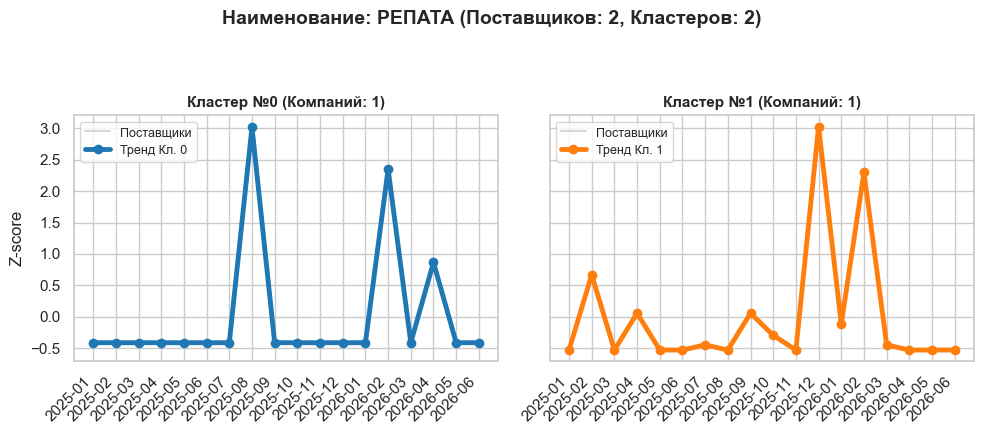

Пропуск 'СИМУЛЕКТ': слишком мало поставщиков (1).
Пропуск 'ТАКЗАЙРО': слишком мало поставщиков (1).
Пропуск 'УМАН АЛЬБУМИН': слишком мало поставщиков (1).
Пропуск 'ФИРАЗИР': слишком мало поставщиков (1).


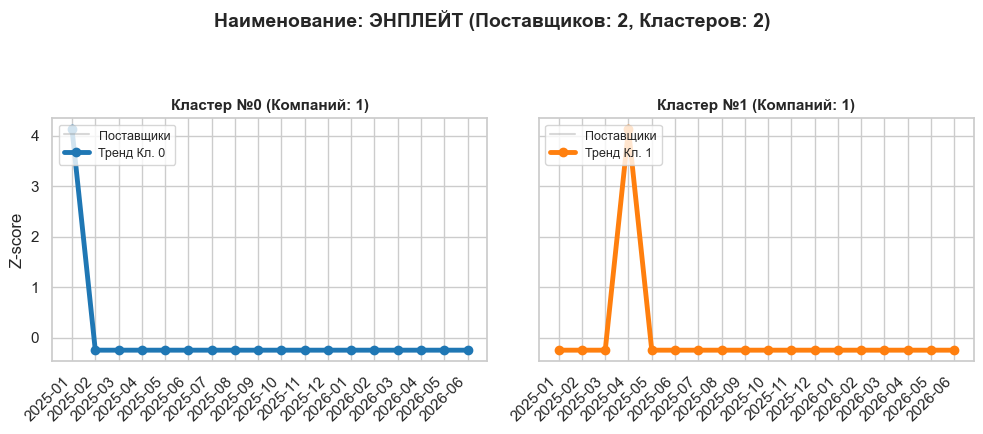

Пропуск 'КЛЕНИЛ УДВ': слишком мало поставщиков (1).


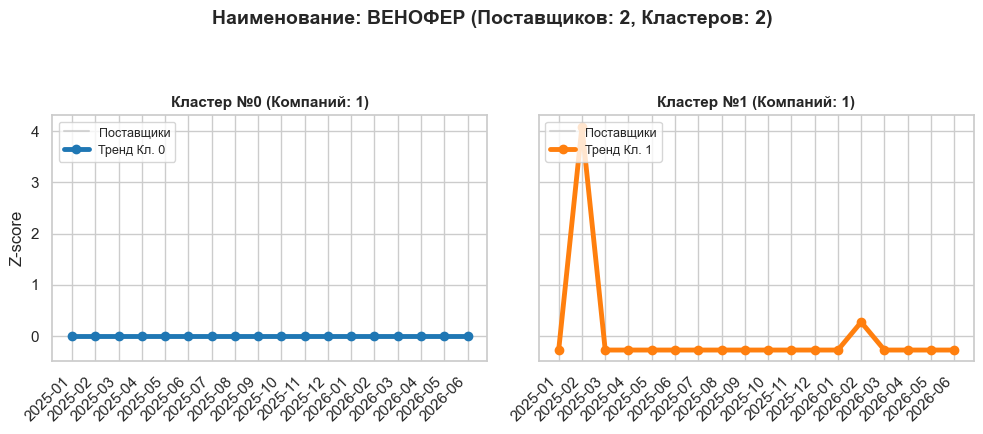

Пропуск 'МАЛЬТОФЕР ФОЛ': слишком мало поставщиков (1).
Пропуск 'ПАРСАБИВ': слишком мало поставщиков (1).
Пропуск 'ФАБРАЗИМ': слишком мало поставщиков (1).


In [ ]:
# выбираем ЧЕТЫРЕ кластера
# последовательно применяем метод кластеризации временных рядов ко всем наименованиям
# Настройка стиля
sns.set_theme(style="whitegrid")

# Список для сборки единого итогового отчета по всем товарам
all_results = []

# Получаем список всех уникальных наименований
unique_items = df_filled['Наименование'].unique()

print(f"Найдено {len(unique_items)} уникальных наименований. Начинаем цикл обработки...")

# Цикл по каждому наименованию
for item in unique_items:
    # 1. Фильтруем данные по текущему наименованию
    df_item = df_filled[df_filled['Наименование'] == item]

    # 2. Строим сводную таблицу для текущего товара
    time_item = pd.pivot_table(
        df_item[['Дата', 'Поставщик', 'Изменение']],
        index=['Дата'],
        columns=['Поставщик'],
        values='Изменение',  # без скобок, чтобы столбцы были плоскими
        aggfunc='sum'
    ).fillna(0.0) # Заполняем пропуски нулями, если поставщик не торговал в этот месяц

    n_suppliers = time_item.shape[1]

    # Проверка: хватает ли поставщиков для кластеризации?
    if n_suppliers < 2:
        print(f"Пропуск '{item}': слишком мало поставщиков ({n_suppliers}).")
        continue

    # 3. Транспонируем и проверяем вариативность данных (защита от деления на 0)
    X_raw = time_item.T.values
    if np.all(np.std(X_raw, axis=1) == 0):
        print(f"Пропуск '{item}': у всех поставщиков абсолютно плоские/нулевые графики.")
        continue

    # 4. Нормируем данные по форме
    scaler = TimeSeriesScalerMeanVariance(mu=0.0, std=1.0)
    X_scaled = scaler.fit_transform(X_raw)

    # Динамически определяем число кластеров ( 4 согласно подбору но не более числа поставщиков)
    current_k = min(4, n_suppliers)

    # 5. Обучаем модель DTW
    model = TimeSeriesKMeans(
        n_clusters=current_k,
        metric="dtw",
        metric_params={"global_constraint": "sakoe_chiba", "sakoe_chiba_radius": 2},
        max_iter=50,
        random_state=42,
        n_jobs=-1
    )
    labels = model.fit_predict(X_scaled)
    centroids = model.cluster_centers_

    # 6. Сохраняем промежуточные результаты текущего товара
    item_results = pd.DataFrame({
        'Наименование': item,
        'Поставщик': time_item.columns,
        'Кластер_Формы': labels
    })
    all_results.append(item_results)

    # 7. Сетке графиков подстраиваем размер под реальное количество получившихся кластеров
    dates_labels = time_item.index.astype(str).str[:7].tolist()
    fig, axes = plt.subplots(1, current_k, figsize=(5 * current_k, 4), sharey=True)
    fig.suptitle(f'Наименование: {item} (Поставщиков: {n_suppliers}, Кластеров: {current_k})',
                 fontsize=14, fontweight='bold', y=1.08)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Если кластер получился всего 1, превращаем axes в массив, чтобы цикл не падал
    if current_k == 1:
        axes = [axes]

    for cluster_id in range(current_k):
        ax = axes[cluster_id]
        cluster_data = X_scaled[labels == cluster_id]

        # Индивидуальные траектории
        for i, series in enumerate(cluster_data):
            lbl = "Поставщики" if i == 0 else ""
            ax.plot(dates_labels, series.ravel(), color='gray', alpha=0.3, linewidth=1.5, label=lbl)

        # Средний тренд (центроид)
        ax.plot(dates_labels, centroids[cluster_id].ravel(), color=colors[cluster_id],
                linewidth=3.5, marker='o', label=f'Тренд Кл. {cluster_id}')

        ax.set_title(f"Кластер №{cluster_id} (Компаний: {len(cluster_data)})", fontsize=11, fontweight='semibold')
        ax.set_xticks(range(len(dates_labels)))
        ax.set_xticklabels(dates_labels, rotation=45, ha='right')
        ax.legend(loc='upper left', fontsize=9)
        if cluster_id == 0:
            ax.set_ylabel("Z-score")

    plt.tight_layout()
    plt.show()

# 8. Объединяем все результаты в один большой финальный реестр
final_report_df = pd.concat(all_results, ignore_index=True)

In [ ]:
final_report_df.head()

,Наименование,Поставщик,Кластер_Формы
0,ИЛСИРА,АО Биокад,3
1,ИЛСИРА,ООО Здравсервис,2
2,ИЛСИРА,ООО Зинтерамед,1
3,ИЛСИРА,ООО Фармфорвард,0
4,ИЛСИРА,ФАРМСТАНДАРТ АО,1


In [ ]:
# для каждого наименования считаю количество кластеров которые сформировали поставщики
final_report_df['КоличествоПоставщиков'] = final_report_df.groupby(['Наименование'])['Поставщик'].transform('nunique')

final_report = final_report_df.groupby(['Наименование']).agg({'Кластер_Формы' : 'nunique',
                            'КоличествоПоставщиков': 'sum'}).reset_index().rename(columns = {'Кластер_Формы':'Количество_кластеров'})

final_report.head(3)

,Наименование,Количество_кластеров,КоличествоПоставщиков
0,АДЕМПАС,4,121
1,АДЦЕТРИС,4,25
2,АЛЬБУМИН,4,1225


In [ ]:
median_suppliers = final_report['КоличествоПоставщиков'].median()

# Функция разметки торговых наименований стратегиями поставщика в зависимости от количества паттернов поведения других поставщиков в тендерах

def get_supplier_strategy (df):
        group_names = [
            "Группа 1: Прозрачный масс-маркет (Стабильные цены / Много поставщиков)",
            "Группа 2: Продуктовый консенсус (Стабильные цены / Мало поставщиков)",
            "Группа 3: Живая биржевая конкуренция (Волатильные цены / Много поставщиков)",
            "Группа 4: Рыночные качели (Волатильные цены / Мало поставщиков)",
            "Группа 5: Спекулятивный туман (Хаотичные цены / Много поставщиков)",
            "Группа 6: Абсолютная ценовая анархия (Хаотичные цены / Мало поставщиков)",
            "Группа 7: Фрагментированный лабиринт (Гипернишевые цены / Много поставщиков)",
            "Группа 8: Абсолютная олигополия (Изолированные монопольные ниши / Мало поставщиков)"
        ]

        strategies = [
            "Оптимизация затрат и масштабирование. Снижать внутренние издержки, брать объемами поставок, автоматизировать логистику. Ценовая война бессмысленна.",
            "Удержание доли рынка и сервисный апгрейд. Держать цену на уровне конкурентов, но выигрывать за счет отсрочек платежей, скорости доставки и безупречного сервиса.",
            "Динамическое ценообразование (Репрайсинг). Мониторить конкурентов в реальном времени, заходить в торги с гибкой ценой, вовремя переключаться между дешевым и дорогим сегментом.",
            "Нишевое позиционирование. Поставщику выгодно занять один из двух ценовых кластеров и стать там главным экспертом, избегая прямой лобовой конкуренции с остальными 2-3 игроками.",
            "Информационное доминирование и агрессивный маркетинг. Формировать уникальные комплексные предложения, скрывать реальную маржу за доп. услугами, ловить невнимательных закупщиков.",
            "Максимизация маржинальности (Снятие сливок). Диктовать свои условия рынку, закладывать максимальные риски в цену, так как у закупщика практически нет альтернатив.",
            "Микротаргетинг и экосистемный подход. Сфокусироваться на 1-2 изолированных микронишах (например, только ультра-премиум) и удерживать клиента за счет кастомизации продукта и сервисных бонусов.",
            "Разделяй и властвуй (Ценовая дискриминация). Использовать многобрендовость. Выгодно присутствовать во всех 4-х кластерах под разными марками, собирая маржу как с эконома, так и с премиума."
        ]

        conds = [
            (df['Количество_кластеров'] == 1) & (df['КоличествоПоставщиков'] > median_suppliers),
            (df['Количество_кластеров'] == 1) & (df['КоличествоПоставщиков'] <= median_suppliers),
            (df['Количество_кластеров'] == 2) & (df['КоличествоПоставщиков'] > median_suppliers),
            (df['Количество_кластеров'] == 2) & (df['КоличествоПоставщиков'] <= median_suppliers),
            (df['Количество_кластеров'] == 3) & (df['КоличествоПоставщиков'] > median_suppliers),
            (df['Количество_кластеров'] == 3) & (df['КоличествоПоставщиков'] <= median_suppliers),
            (df['Количество_кластеров'] == 4) & (df['КоличествоПоставщиков'] > median_suppliers),
            (df['Количество_кластеров'] == 4) & (df['КоличествоПоставщиков'] <= median_suppliers)
        ]

        df['Название_Группы'] = np.select(conds, group_names, default="Неизвестная группа")
        df['Стратегия'] = np.select(conds, strategies, default="Нет стратегии")

        return df

# Применяем функцию (разделяем кортеж на две новые колонки)
final_report_out = get_supplier_strategy(final_report)

final_report_out.head()


,Наименование,Количество_кластеров,КоличествоПоставщиков,Название_Группы,Стратегия
0,АДЕМПАС,4,121,Группа 7: Фрагментированный лабиринт (Гиперниш...,Микротаргетинг и экосистемный подход. Сфокусир...
1,АДЦЕТРИС,4,25,Группа 8: Абсолютная олигополия (Изолированные...,Разделяй и властвуй (Ценовая дискриминация). И...
2,АЛЬБУМИН,4,1225,Группа 7: Фрагментированный лабиринт (Гиперниш...,Микротаргетинг и экосистемный подход. Сфокусир...
3,АЛЬБУМИН ЧЕЛОВЕЧЕСКИЙ,4,121,Группа 7: Фрагментированный лабиринт (Гиперниш...,Микротаргетинг и экосистемный подход. Сфокусир...
4,АНТИТРОМБИН III ЧЕЛОВЕЧЕСКИЙ,3,9,Группа 6: Абсолютная ценовая анархия (Хаотичны...,Максимизация маржинальности (Снятие сливок). Д...


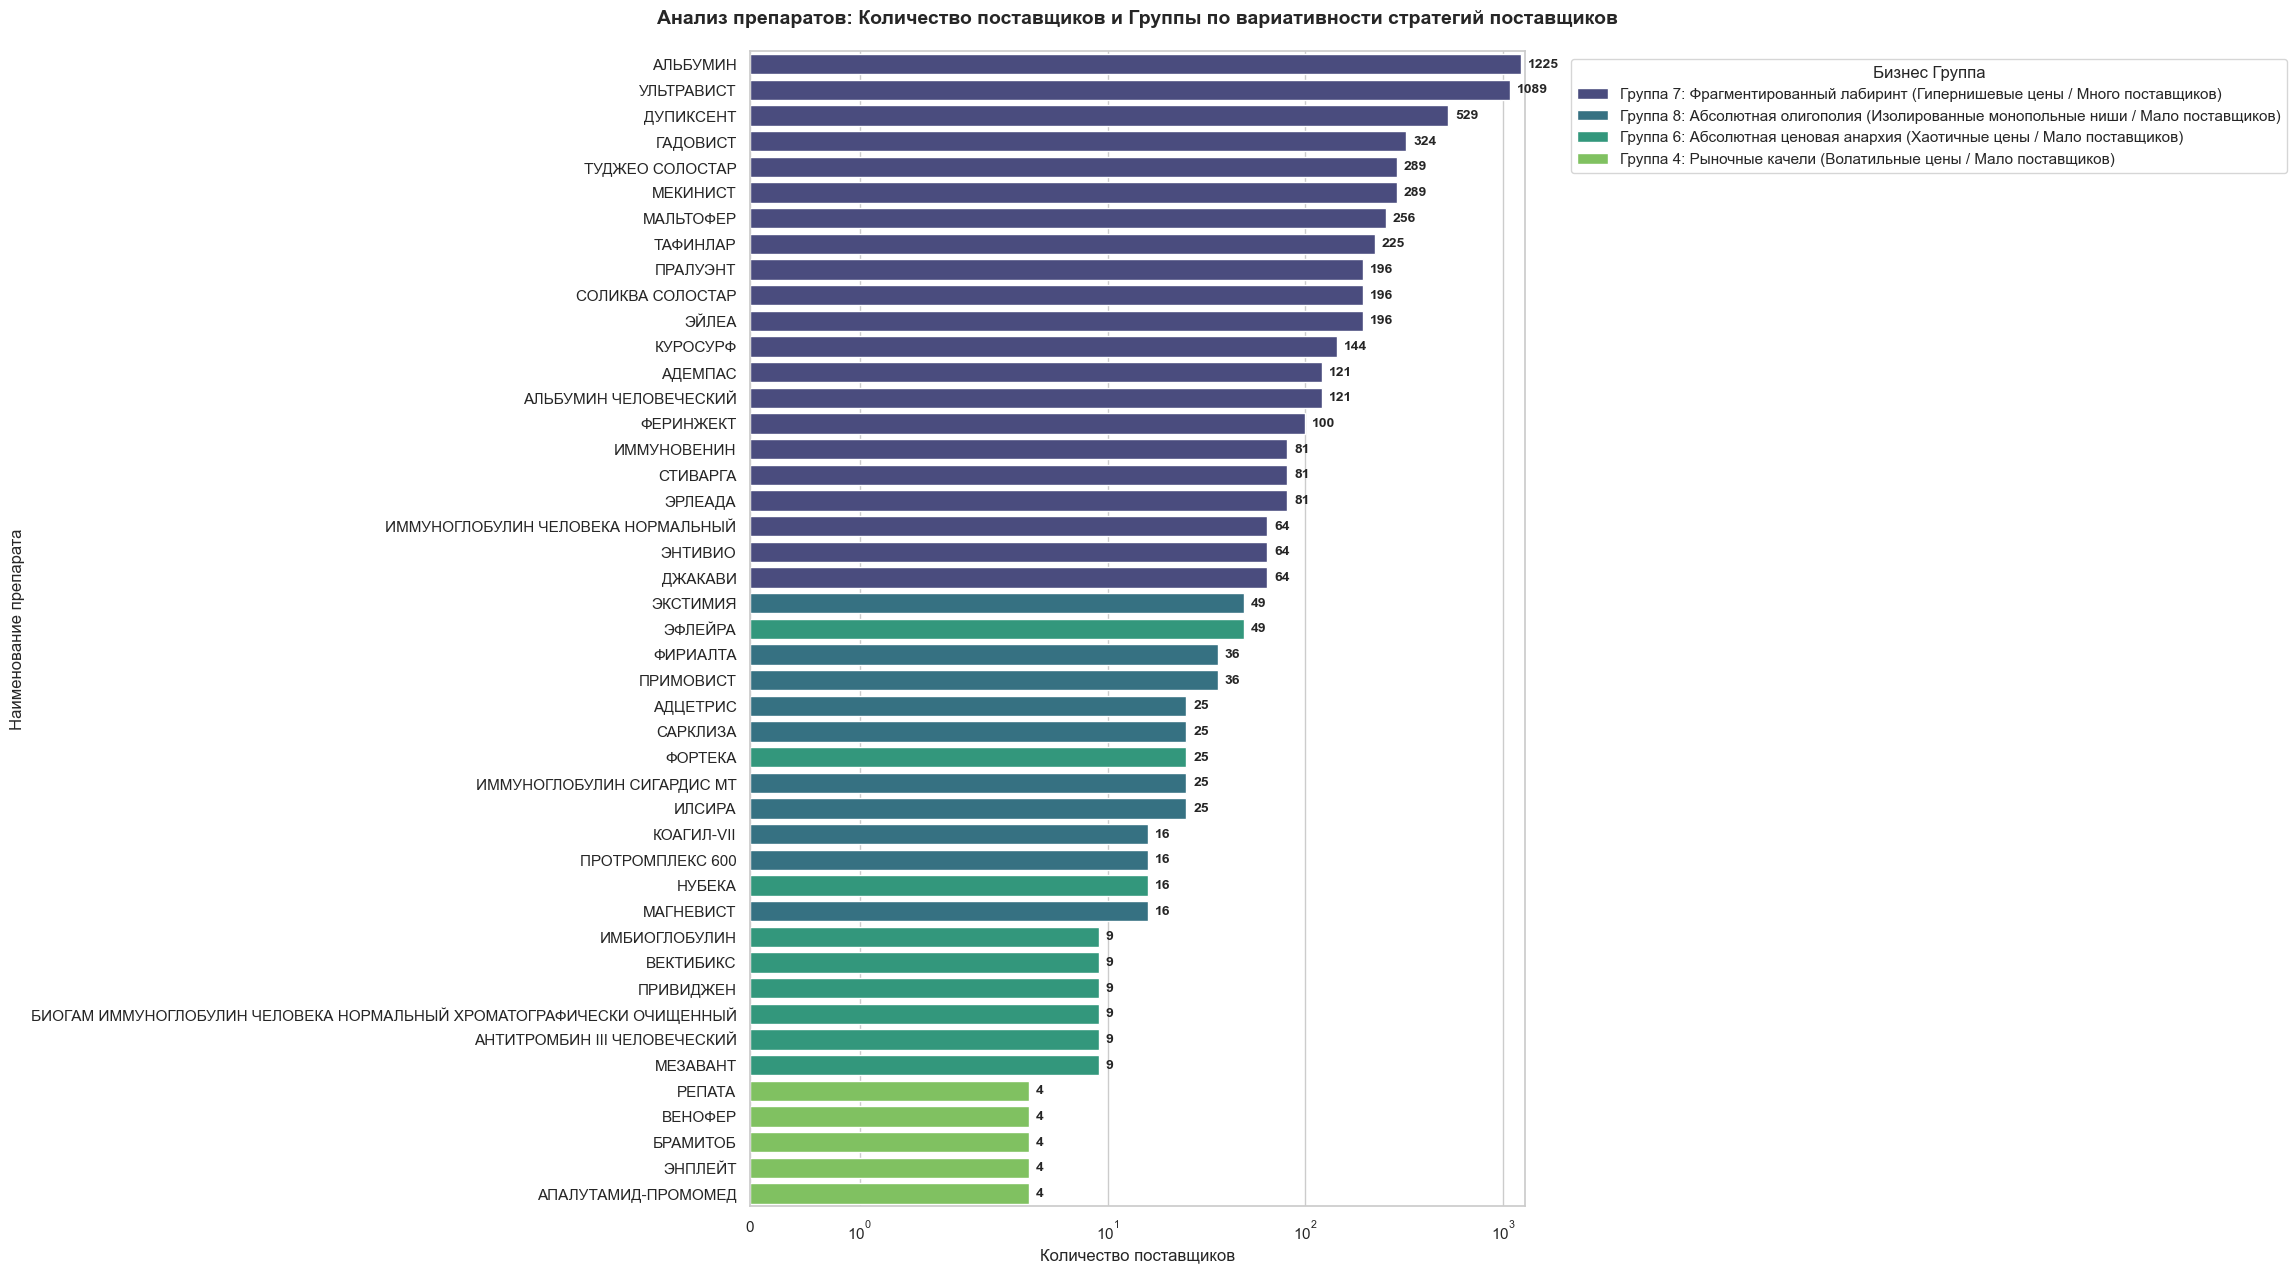

In [ ]:
import base64
import io


# Сортируем данные для красивого отображения
df = final_report.sort_values(by="КоличествоПоставщиков", ascending=False)

# 2. Настройка стиля и создание графика
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 15))

# Построение горизонтального Barplot
# hue разделяет столбцы по цветам в зависимости от Бизнес_Группы
ax = sns.barplot(
    x="КоличествоПоставщиков",
    y="Наименование",
    hue="Название_Группы",
    data=df,
    palette="viridis",
    dodge=False,
)

# 3. Настройка осей и логарифмической шкалы
# Используем симметричный лог, так как разброс значений огромный (от 4 до 529)
ax.set_xscale("symlog")

# Добавляем подписи значений в конце каждого столбца
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, weight="bold")

# Оформление текстовых элементов
plt.title(
    "Анализ препаратов: Количество поставщиков и Группы по вариативности стратегий поставщиков",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Количество поставщиков", fontsize=12)
plt.ylabel("Наименование препарата", fontsize=12)

# Корректируем расположение легенды, чтобы она не перекрывала график
plt.legend(title="Бизнес Группа", bbox_to_anchor=(1.05, 1), loc="upper left")

# Отображение
plt.tight_layout()
plt.show()
